In [4]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from plotnine import *
import pandas as pd

ames = pd.read_csv('ames.csv')

## Grafico de Barras

In [37]:
from plotnine import *
import pandas as pd


df_plot = (
    ames['Bedroom_AbvGr']
    .value_counts()
    .sort_index()
    .reset_index()
)

df_plot.columns = ['Bedroom_AbvGr', 'count']



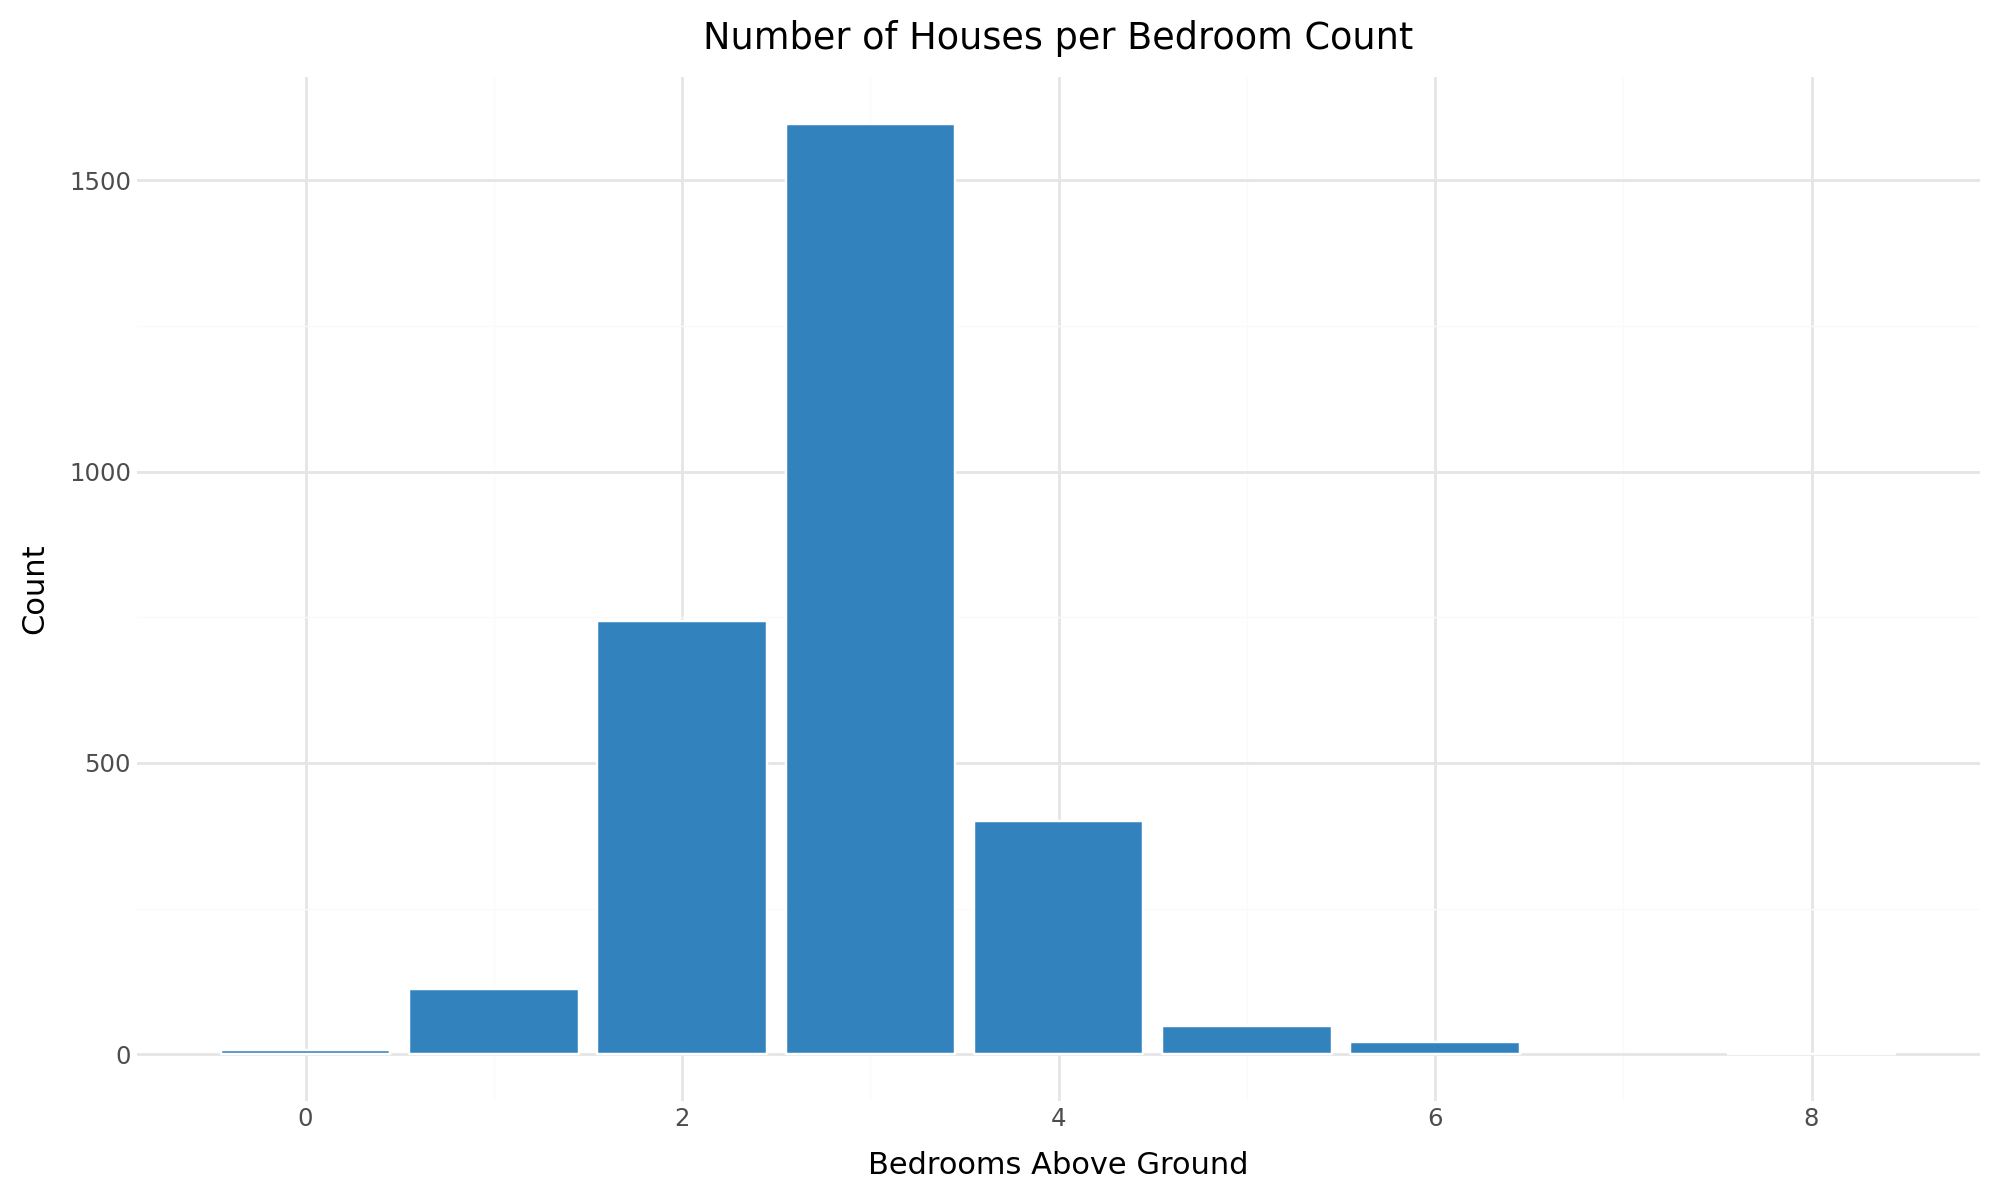

In [38]:
 (
    ggplot(df_plot, aes(x='Bedroom_AbvGr', y='count'))
    + geom_col(fill="#3182bd", color="white")
    + theme_minimal()
    + labs(
        title="Number of Houses per Bedroom Count",
        x="Bedrooms Above Ground",
        y="Count"
    )
    + theme(
        figure_size=(10, 6)
    )
)



In [39]:
ames_grouped = (
    ames.groupby('Neighborhood', as_index=False)['Sale_Price']
        .median()
        .rename(columns={'Sale_Price': 'Mediana_precio'})
)

ames_grouped = ames_grouped.sort_values('Mediana_precio', ascending=False)

ames_grouped['Neighborhood'] = pd.Categorical(
    ames_grouped['Neighborhood'],
    categories=ames_grouped['Neighborhood'],
    ordered=True
)



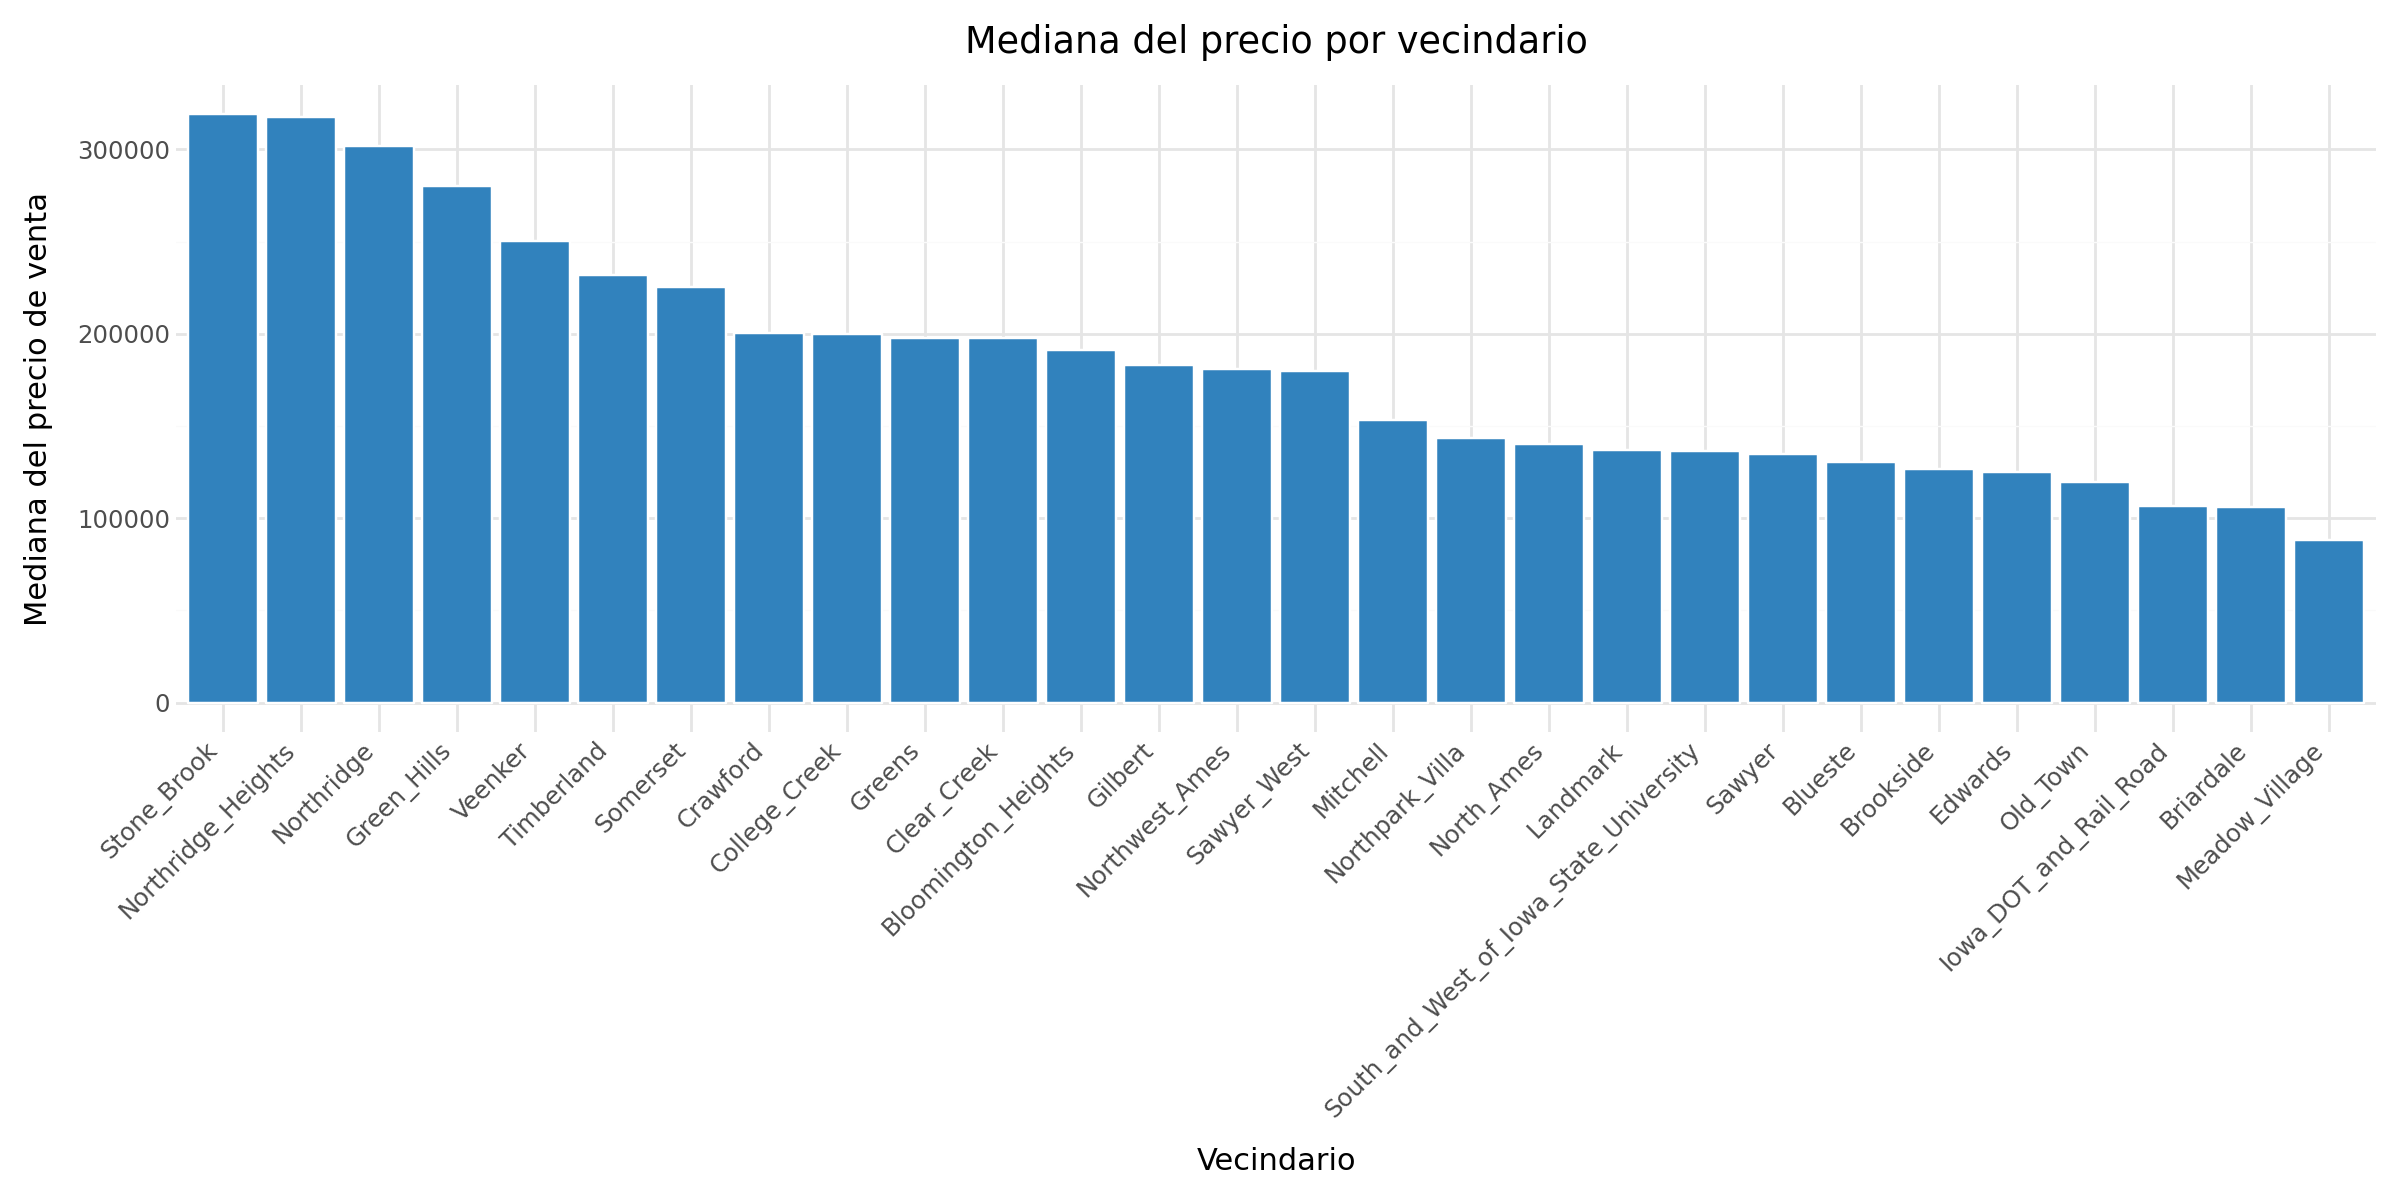

In [40]:
 p = (
    ggplot(ames_grouped, aes(x='Neighborhood', y='Mediana_precio'))
    + geom_col(fill="#3182bd", color="white")
    + theme_minimal()
    + labs(
        title="Mediana del precio por vecindario",
        x="Vecindario",
        y="Mediana del precio de venta"
    )
    + theme(
        figure_size=(12, 6),
        axis_text_x=element_text(rotation=45, ha='right')
    )
)

p


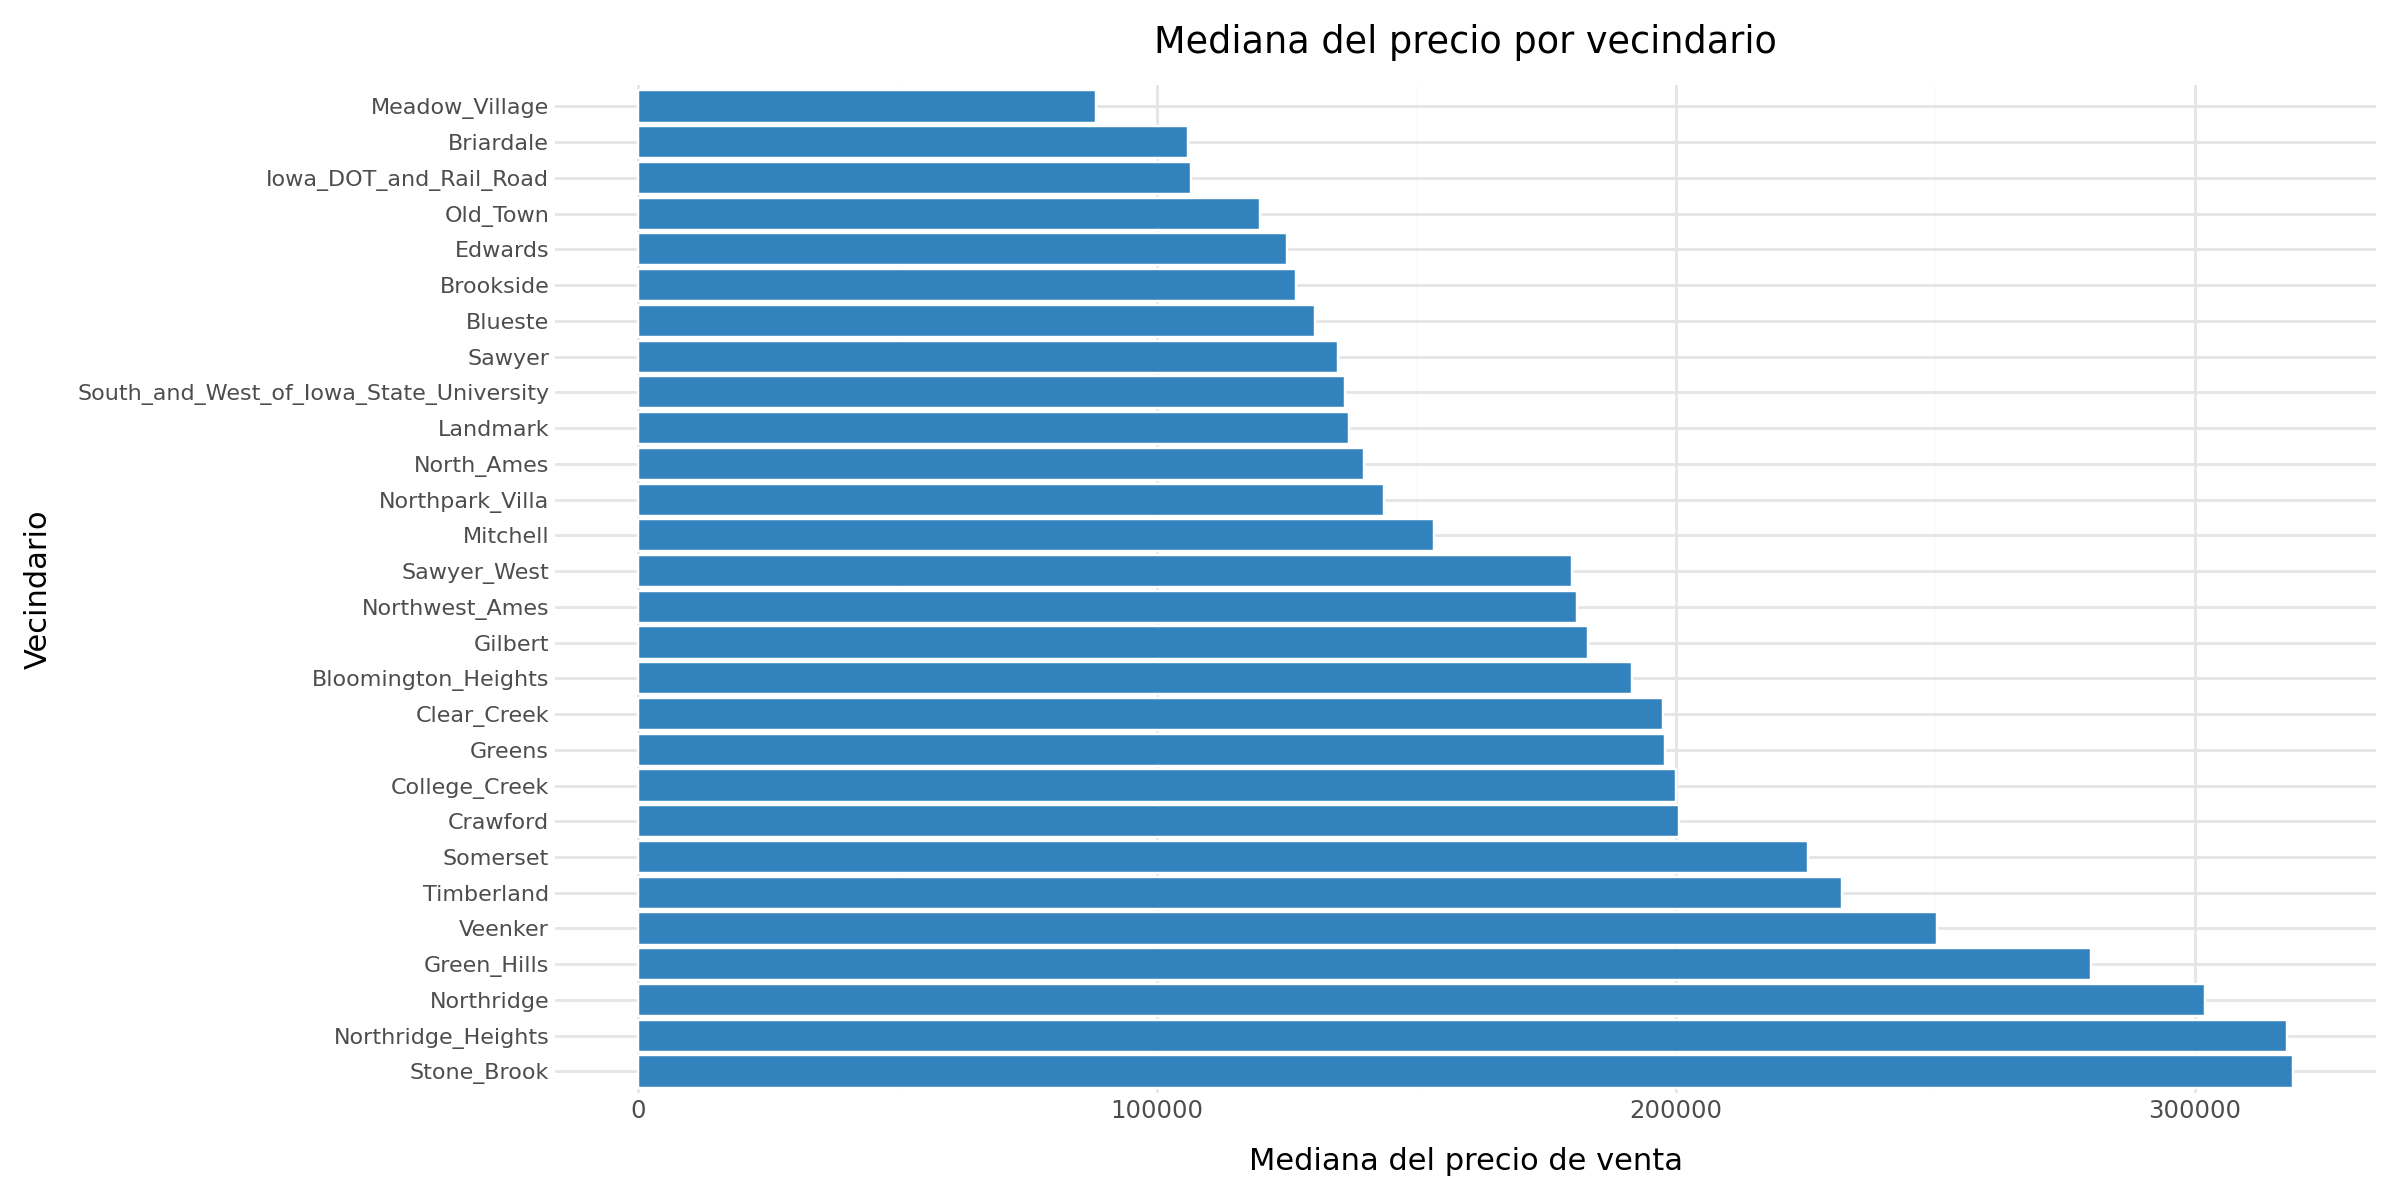

In [41]:
from plotnine import *

p = (
    ggplot(ames_grouped, aes(x='Neighborhood', y='Mediana_precio'))
    + geom_col(fill="#3182bd", color="white")
    + coord_flip()   # <-- makes the bars horizontal
    + theme_minimal()
    + labs(
        title="Mediana del precio por vecindario",
        x="Vecindario",
        y="Mediana del precio de venta"
    )
    + theme(
        figure_size=(12, 6),
        axis_text_y=element_text(size=8)  # rotate not needed when horizontal
    )
)

p

In [42]:
ames_grouped = ames_grouped.sort_values(by='Mediana_precio', 
                                        ascending=False)

# Convertir Neighborhood en categórica con este orden
ames_grouped['Neighborhood'] = pd.Categorical(
    ames_grouped['Neighborhood'],
    categories=ames_grouped['Neighborhood'],
    ordered=True
)


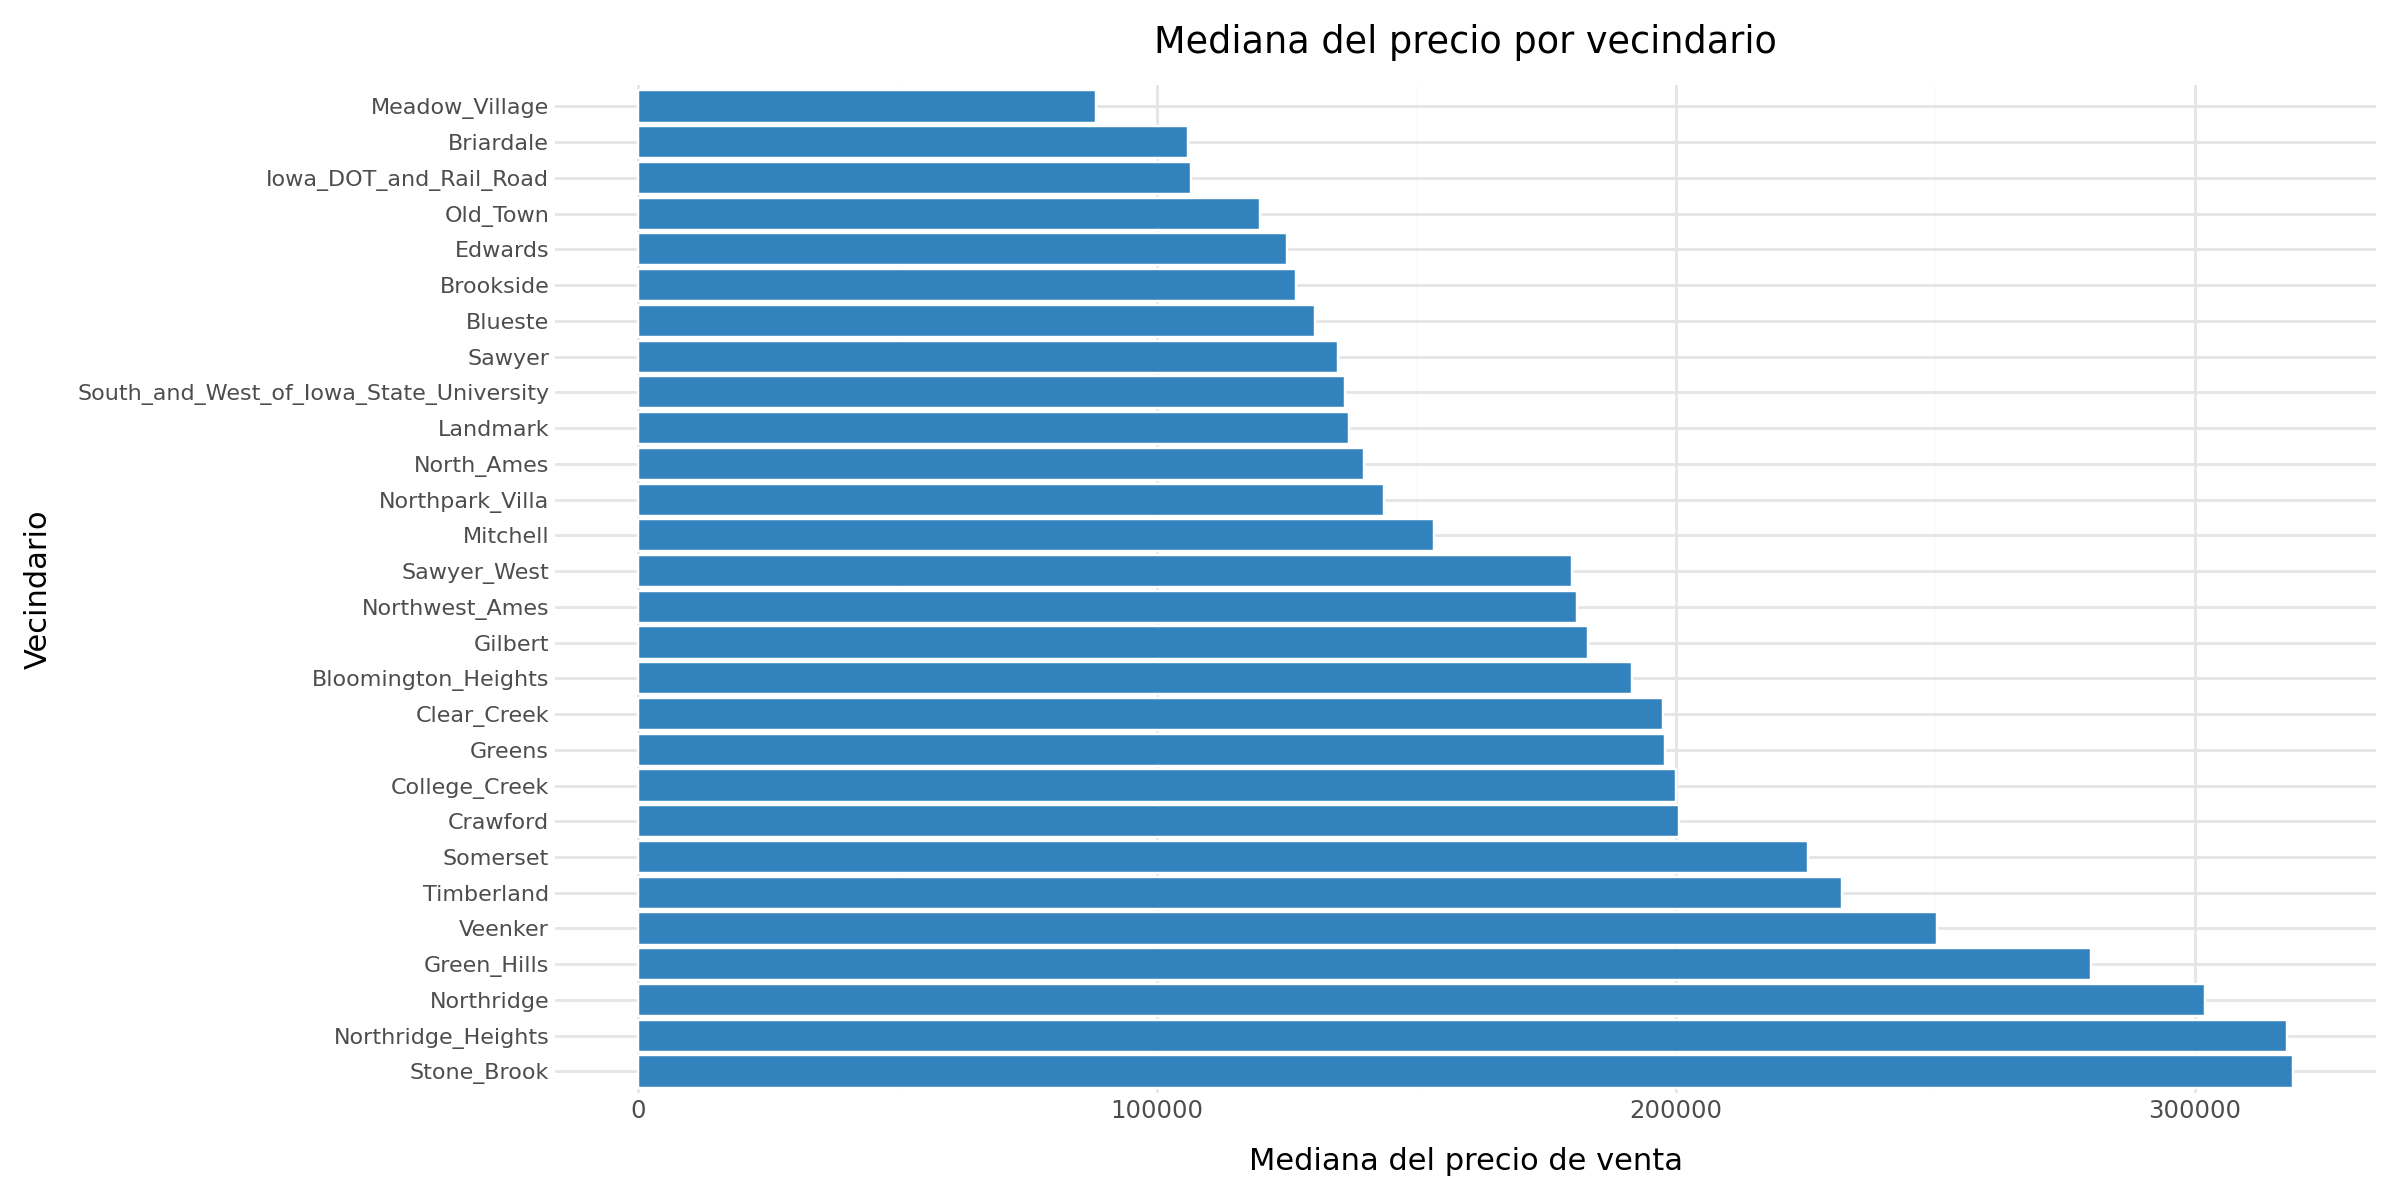

In [43]:
from plotnine import *

p = (
    ggplot(ames_grouped, aes(x='Neighborhood', y='Mediana_precio'))
    + geom_col(fill="#3182bd", color="white")
    + coord_flip()
    + theme_minimal()
    + labs(
        title="Mediana del precio por vecindario",
        x="Vecindario",
        y="Mediana del precio de venta"
    )
    + theme(
        figure_size=(12, 6),
        axis_text_y=element_text(size=8)
    )
)

p

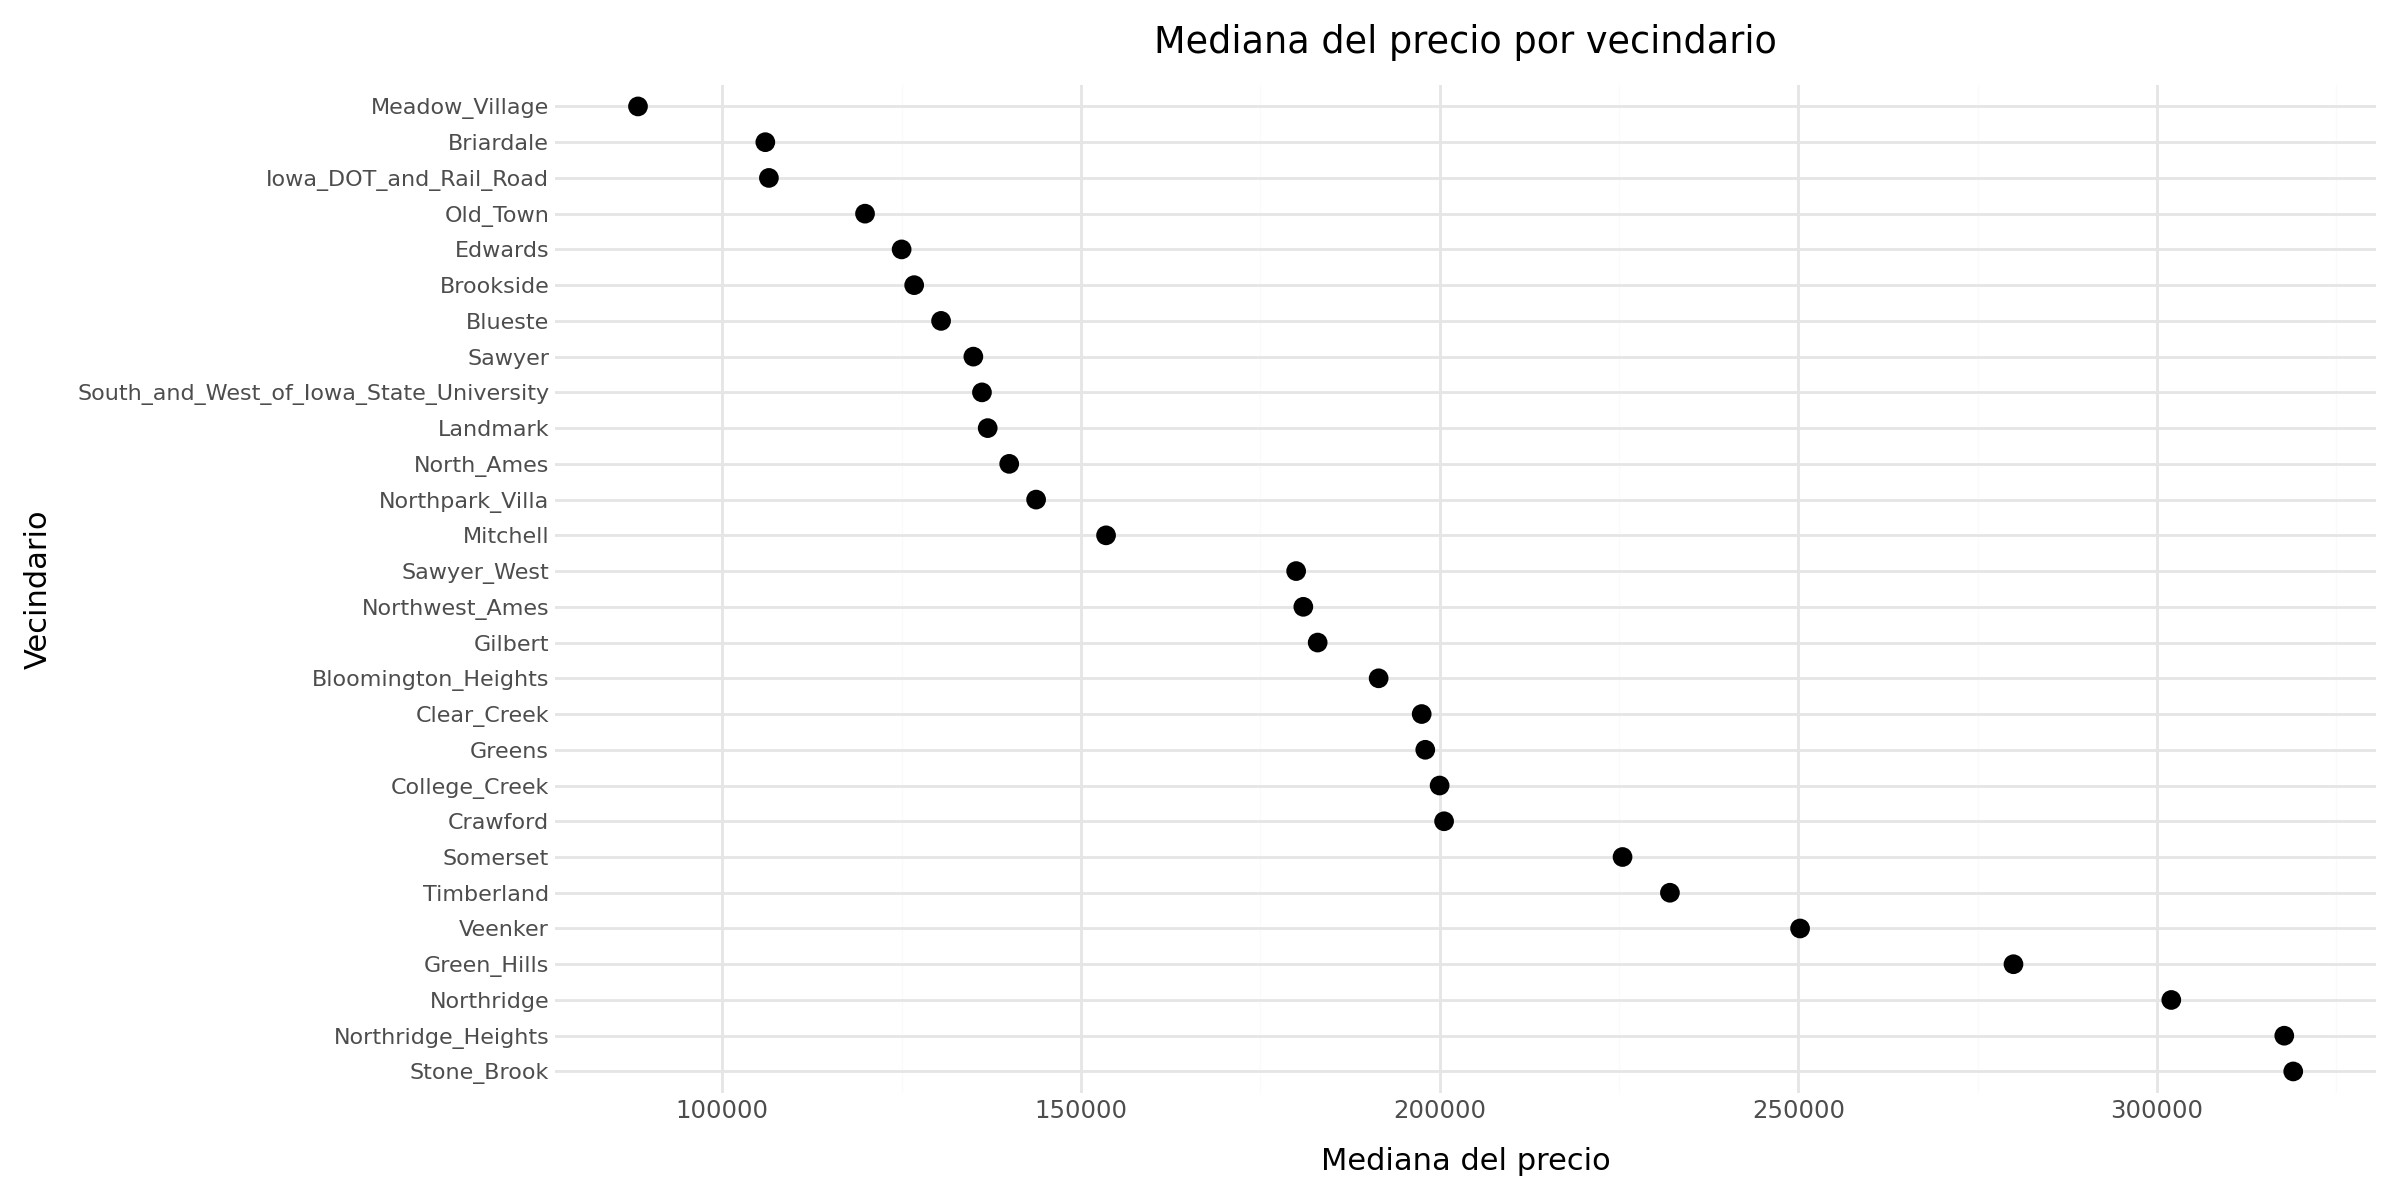

In [44]:
from plotnine import *

p = (
    ggplot(ames_grouped, aes(x='Mediana_precio', y='Neighborhood'))
    + geom_point(color='black', size=3)   # size≈3 matches seaborn s=100 visually
    + theme_minimal()
    + labs(
        title="Mediana del precio por vecindario",
        x="Mediana del precio",
        y="Vecindario"
    )
    + theme(
        figure_size=(12, 6),
        axis_text_y=element_text(size=8)
    )
)

p

# Histogramas

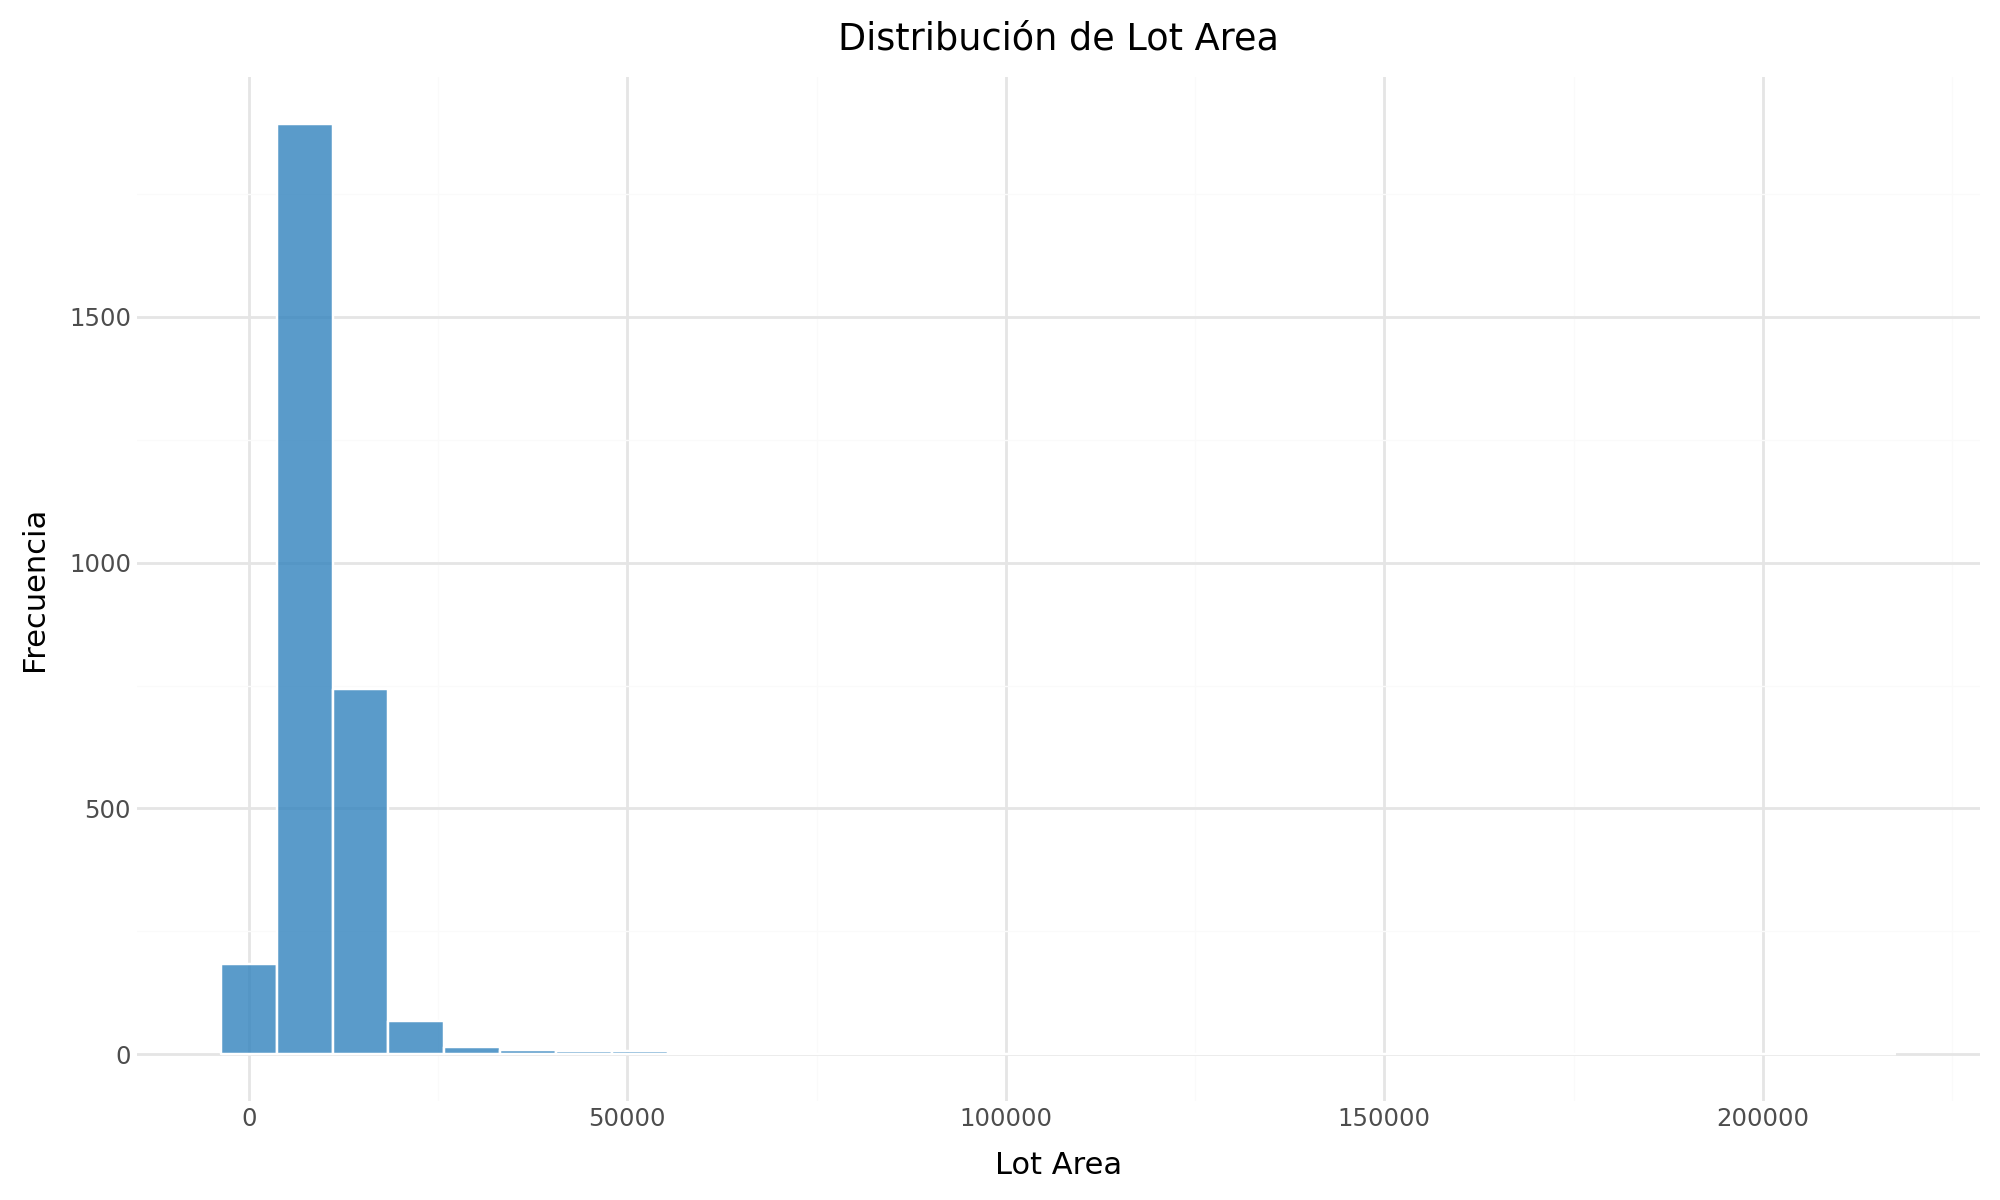

In [45]:
p = (
    ggplot(ames, aes(x='Lot_Area'))
    + geom_histogram(
        bins=30,
        fill="#3182bd",
        color="white",
        alpha=0.8
    )
    + theme_minimal()
    + labs(
        title="Distribución de Lot Area",
        x="Lot Area",
        y="Frecuencia"
    )
    + theme(
        figure_size=(10, 6)
    )
)

p

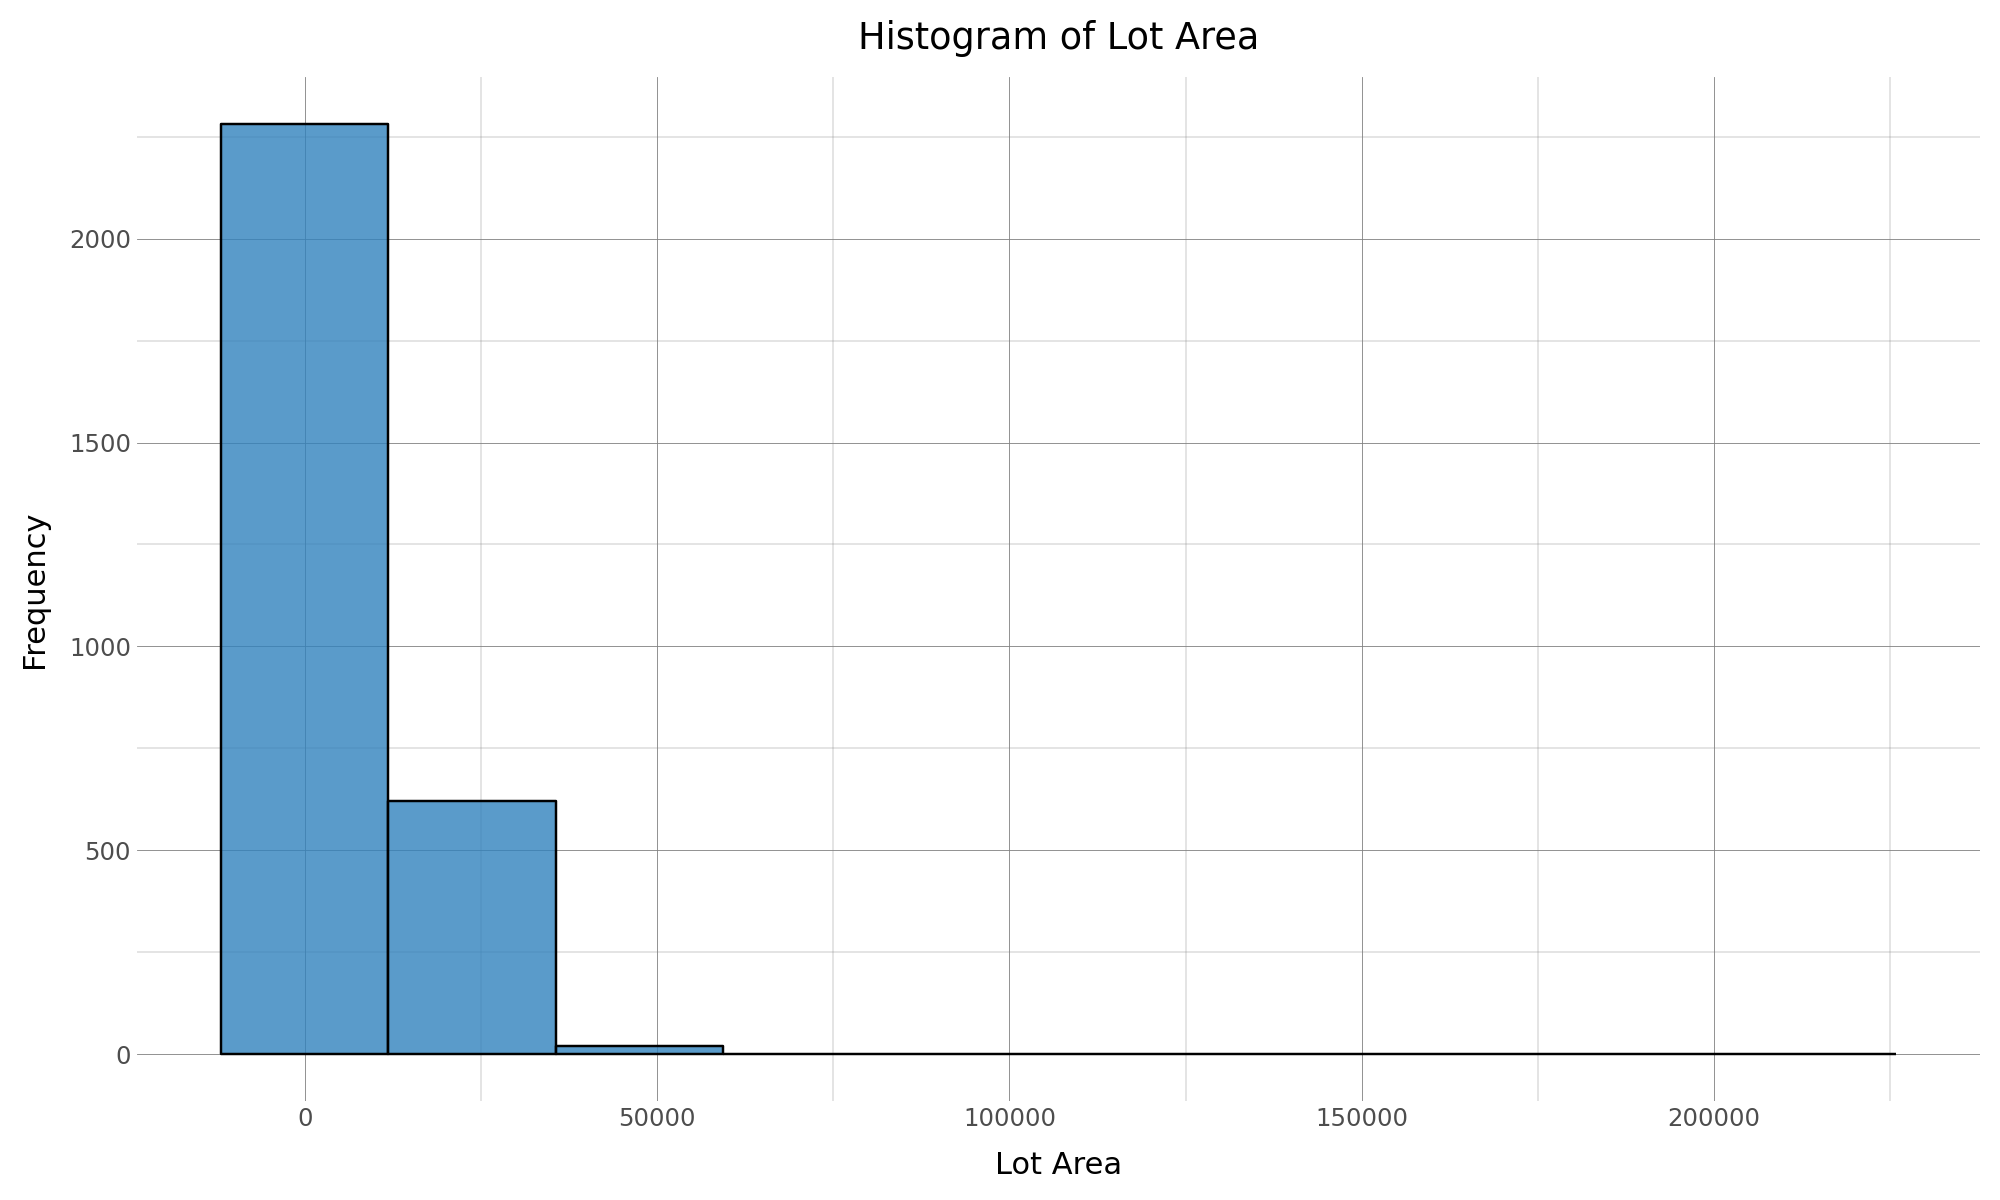

In [46]:
p = (
    ggplot(ames, aes(x='Lot_Area'))
    + geom_histogram(
        bins=10,
        fill="#3182bd",
        color="black",     # equivalent to edgecolor='black'
        alpha=0.8
    )
    + theme_minimal()
    + labs(
        title="Histogram of Lot Area",
        x="Lot Area",
        y="Frequency"
    )
    + theme(
        figure_size=(10, 6),
        panel_grid_major=element_line(color="gray", size=0.3),   # grid=True equivalent
        panel_grid_minor=element_line(color="gray", size=0.15)
    )
)

p


## Densidad

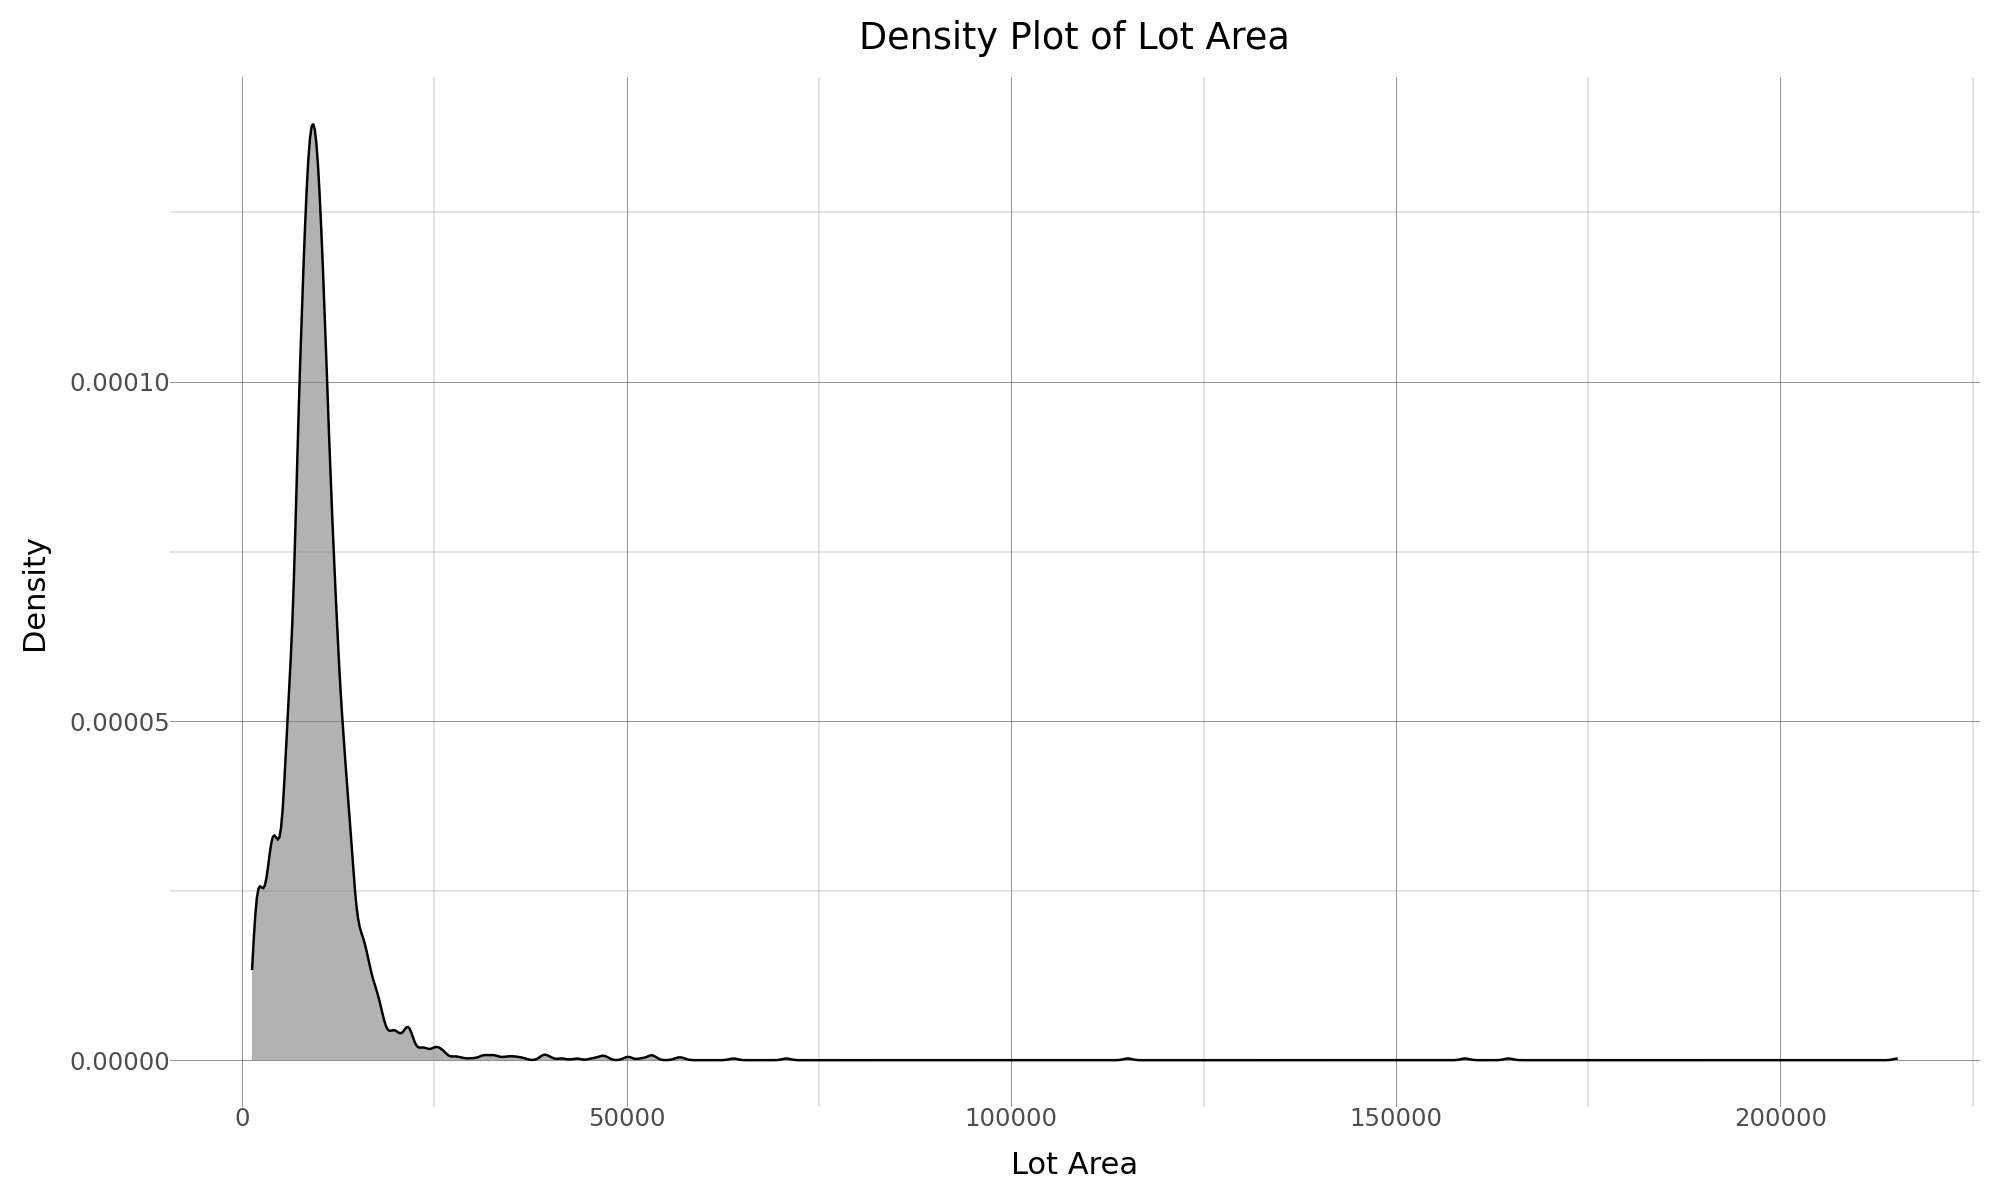

In [5]:
#pip install -U pandas statsmodels plotnine mizani
#pip install "pandas==2.1.4" "statsmodels==0.14.1" "plotnine==0.13.6" "mizani==0.11.4"
#from plotnine import *
#import statsmodels
#from statsmodels.compat.pandas import FUTURE_STACK
#from statsmodels.compat.python import lzip
#import datetime

p = (
    ggplot(ames, aes(x='Lot_Area'))
    + geom_density(
        fill="grey",   # same idea as shade=True
        alpha=0.6,
        color="black"  # outline similar to seaborn default
    )
    + theme_minimal()
    + labs(
        title="Density Plot of Lot Area",
        x="Lot Area",
        y="Density"
    )
    + theme(
        figure_size=(10, 6),
        panel_grid_major=element_line(color="gray", size=0.3),
        panel_grid_minor=element_line(color="gray", size=0.15)
    )
)

p

## Histograma & Densidad

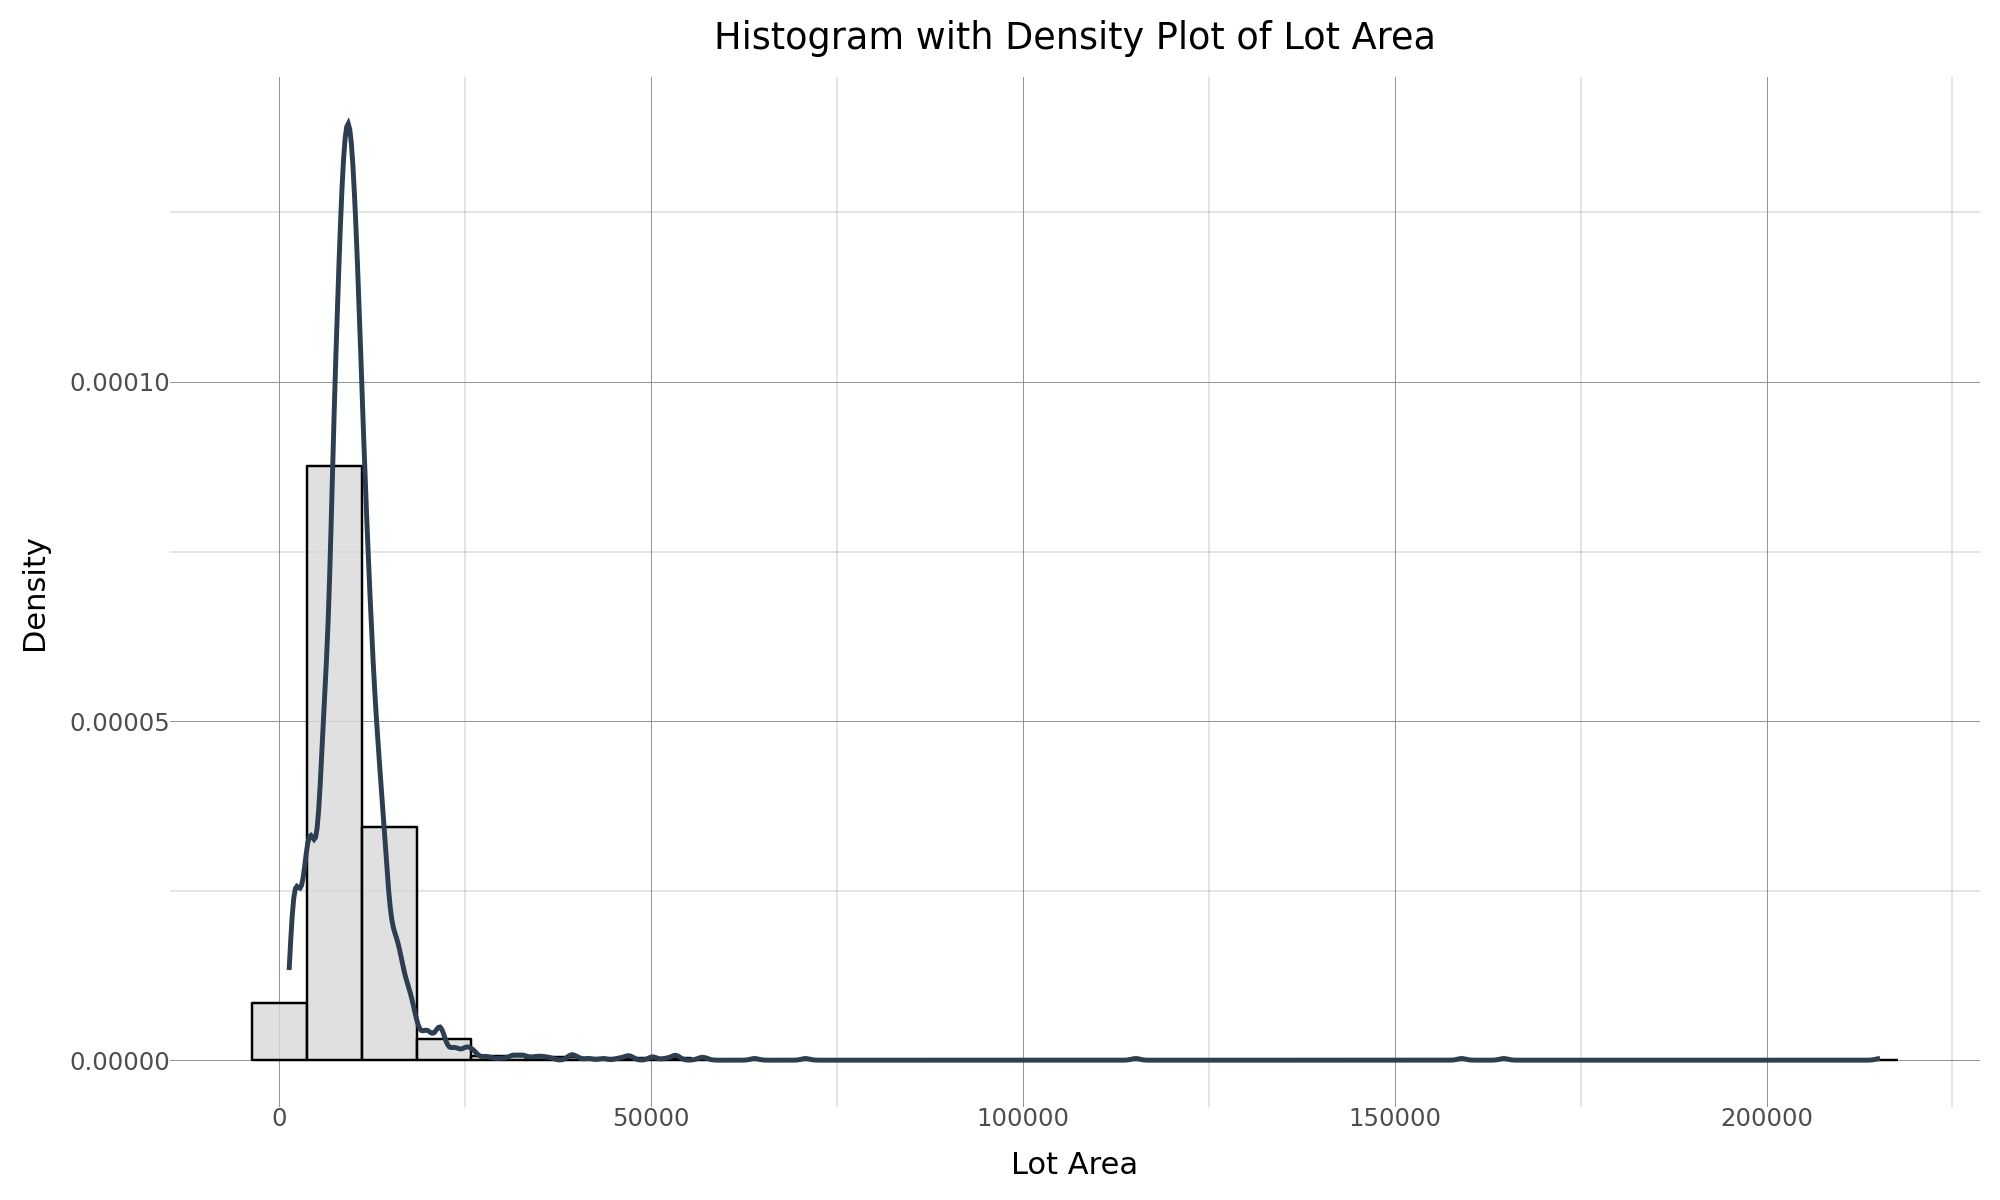

In [8]:
from plotnine import *

p = (
    ggplot(ames, aes(x='Lot_Area'))
    + geom_histogram(
        mapping=aes(y=after_stat('density')),  # mapping first (as keyword)
        bins=30,
        fill="#d9d9d9",
        color="black",
        alpha=0.8
    )
    + geom_density(color="#2c3e50", size=1.0, fill=None)
    + labs(
        title="Histogram with Density Plot of Lot Area",
        x="Lot Area",
        y="Density"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        panel_grid_major=element_line(color="gray", size=0.3),
        panel_grid_minor=element_line(color="gray", size=0.15)
    )
)

p

C:\Users\cecir\AppData\Local\Temp\ipykernel_5336\1523035246.py:24: FutureWarning: Using print(plot) to draw and show the plot figure is deprecated and will be removed in a future version. Use plot.show().


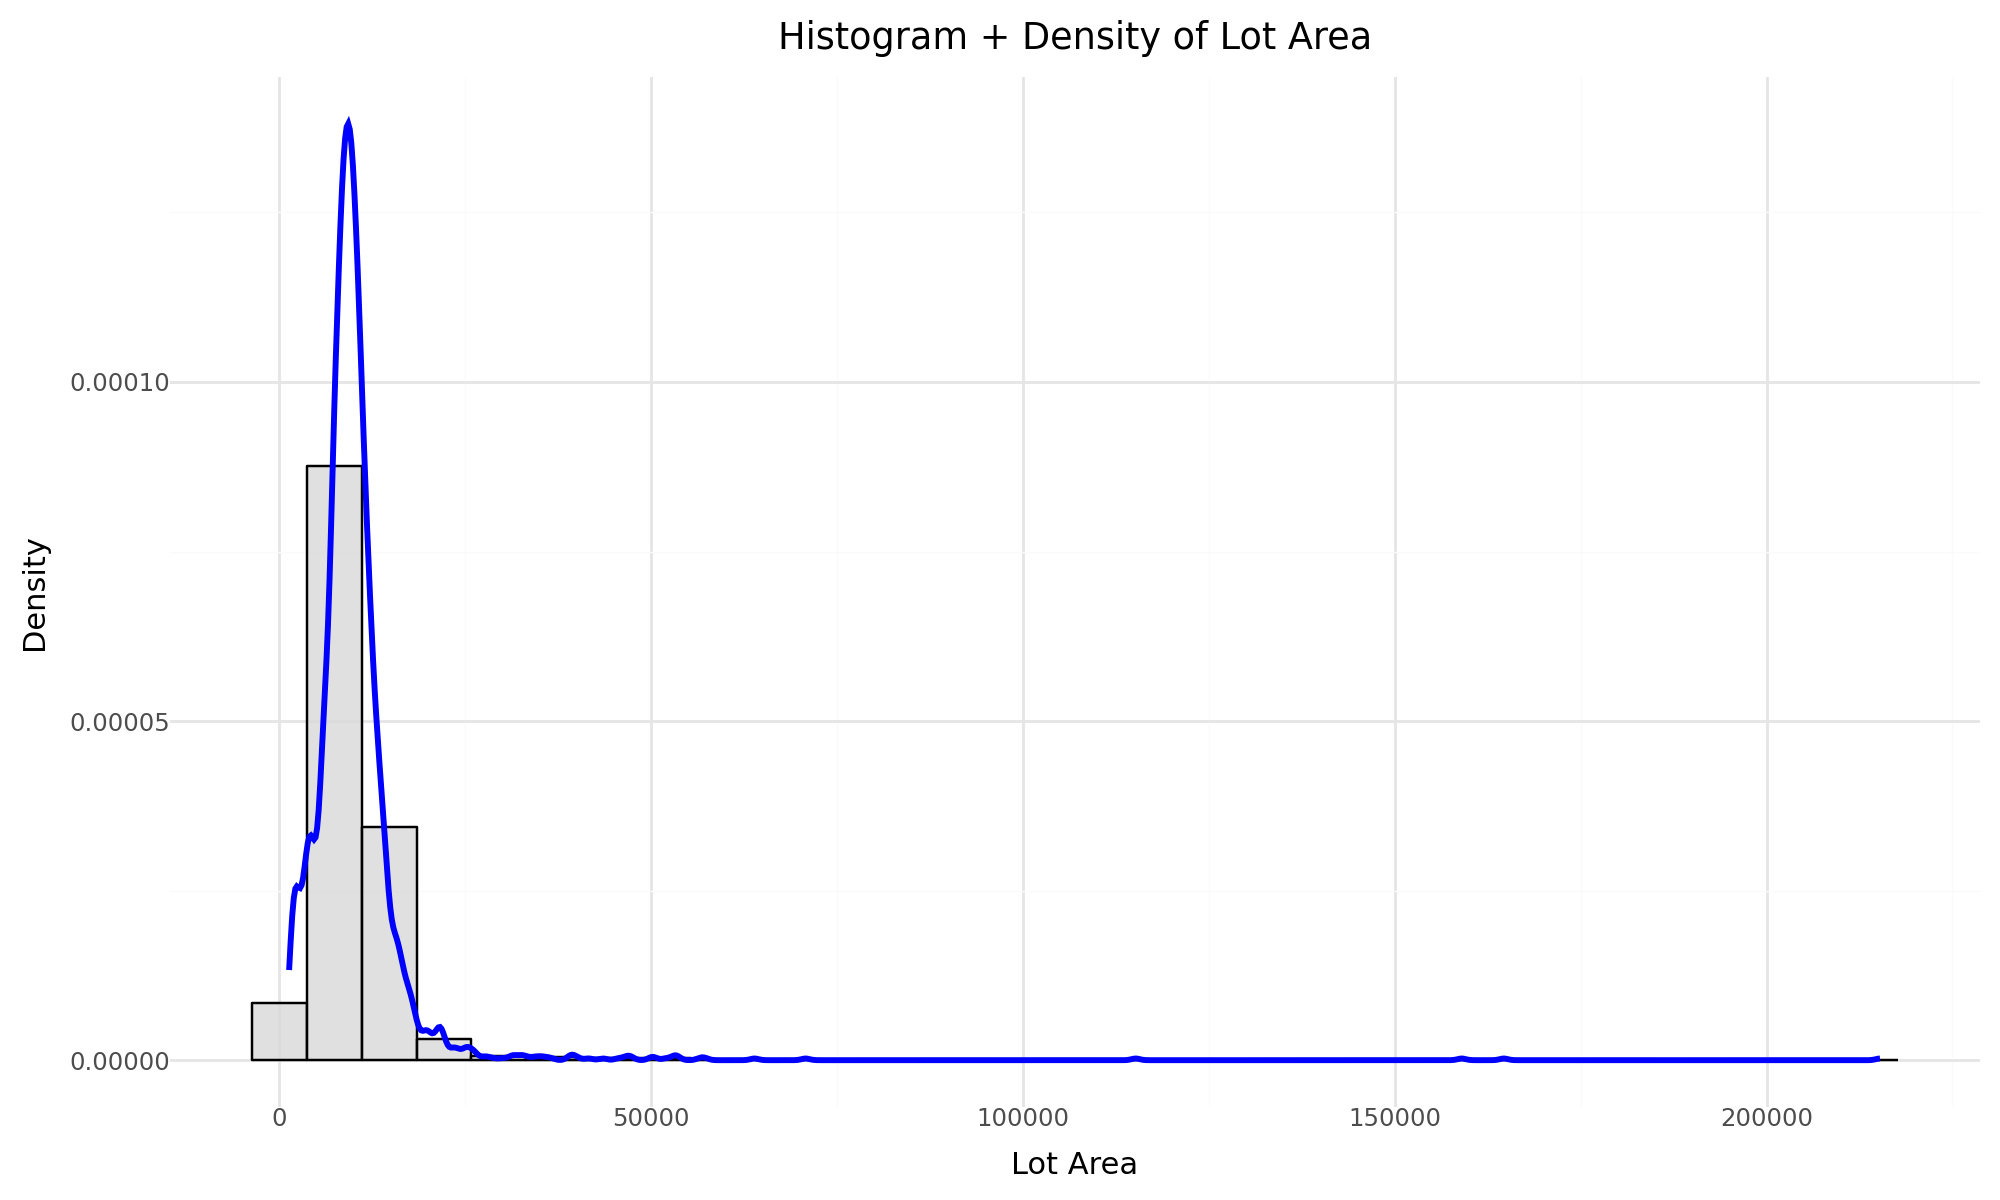

In [9]:
from plotnine import *

p = (
    ggplot(ames, aes(x='Lot_Area'))
    # Histogram normalized to density (same as distplot default)
    + geom_histogram(
        mapping=aes(y=after_stat('density')),
        bins=30,
        fill="#d9d9d9",
        color="black",
        alpha=0.8
    )
    # KDE curve
    + geom_density(color="blue", size=1.2)
    + labs(
        title="Histogram + Density of Lot Area",
        x="Lot Area",
        y="Density"
    )
    + theme_minimal()
    + theme(figure_size=(10, 6))
)

print(p)

## Proporciones 

### forma 1

In [36]:
prop_counts = ames['Bedroom_AbvGr'].value_counts(normalize=True).sort_index()


In [10]:
import pandas as pd
from plotnine import *

# 1) Compute proportions and put them into a DataFrame
prop_counts = (
    ames['Bedroom_AbvGr']
    .value_counts(normalize=True)
    .sort_index()
    .rename('proportion')
    .reset_index()
    .rename(columns={'index': 'Bedroom_AbvGr'})
)

# 2) Make Bedroom_AbvGr categorical to keep sorted order on the x-axis
prop_counts['Bedroom_AbvGr'] = pd.Categorical(
    prop_counts['Bedroom_AbvGr'],
    categories=prop_counts['Bedroom_AbvGr'],
    ordered=True
)



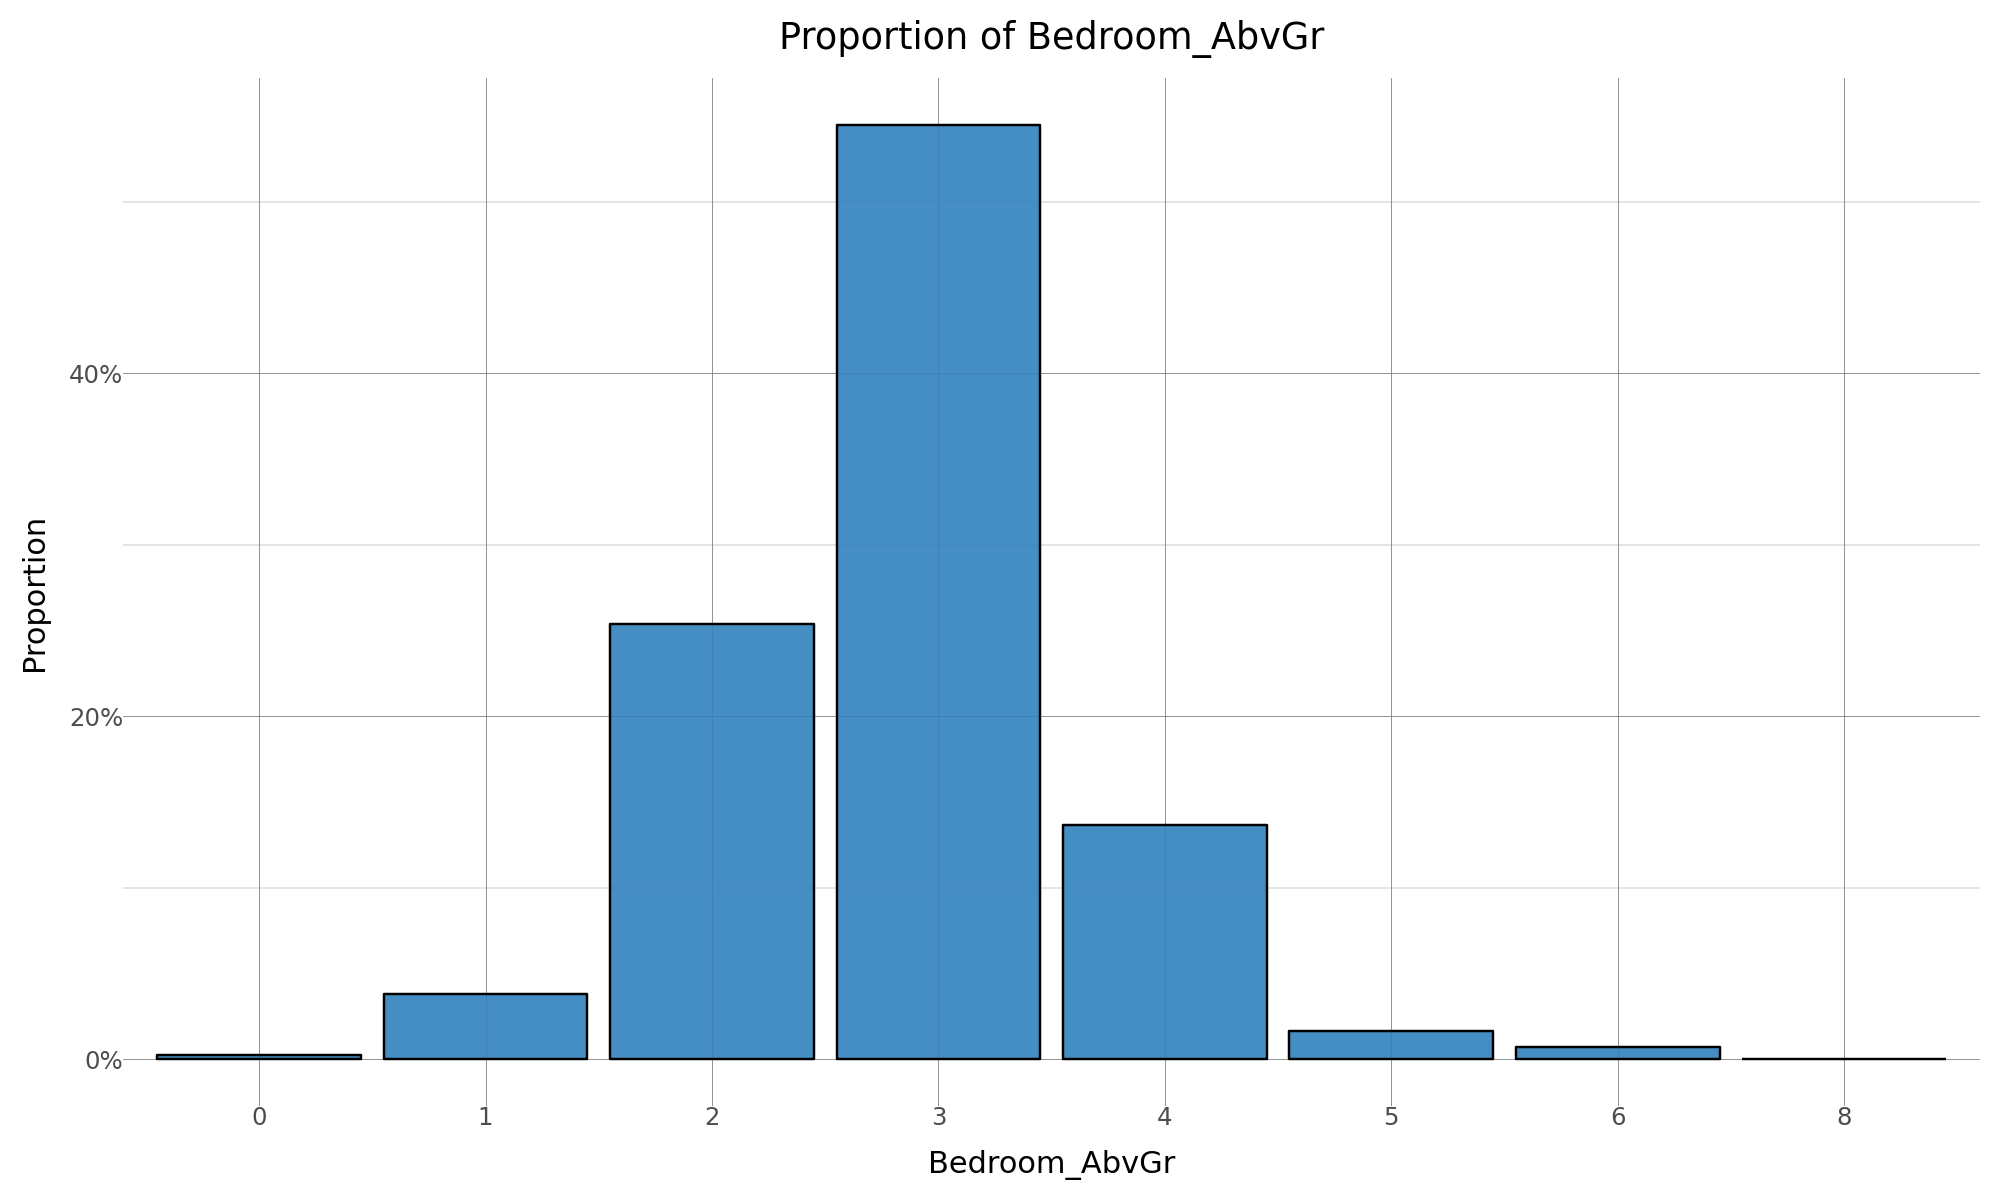

In [11]:
p = (
    ggplot(prop_counts, aes(x='Bedroom_AbvGr', y='proportion'))
    + geom_col(fill="#3182bd", color="black", alpha=0.9)
    + scale_y_continuous(labels=lambda l: [f"{v:.0%}" for v in l])  # format as percentages
    + labs(
        title="Proportion of Bedroom_AbvGr",
        x="Bedroom_AbvGr",
        y="Proportion"
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        panel_grid_major=element_line(color="gray", size=0.3),
        panel_grid_minor=element_line(color="gray", size=0.15)
    )
)

p

In [15]:
#prop_counts = ames['Bedroom_AbvGr'].value_counts(normalize=True).sort_index() * 100

prop_counts = (
    ames['Bedroom_AbvGr']
    .value_counts(normalize=True)
    .sort_index()
    * 100
)



prop_counts_df = (
    ames['Bedroom_AbvGr']
    .value_counts(normalize=True)
    .sort_index()
    .mul(100)
    .rename('proportion')
    .reset_index()
    .rename(columns={'index': 'Bedroom_AbvGr'})
)


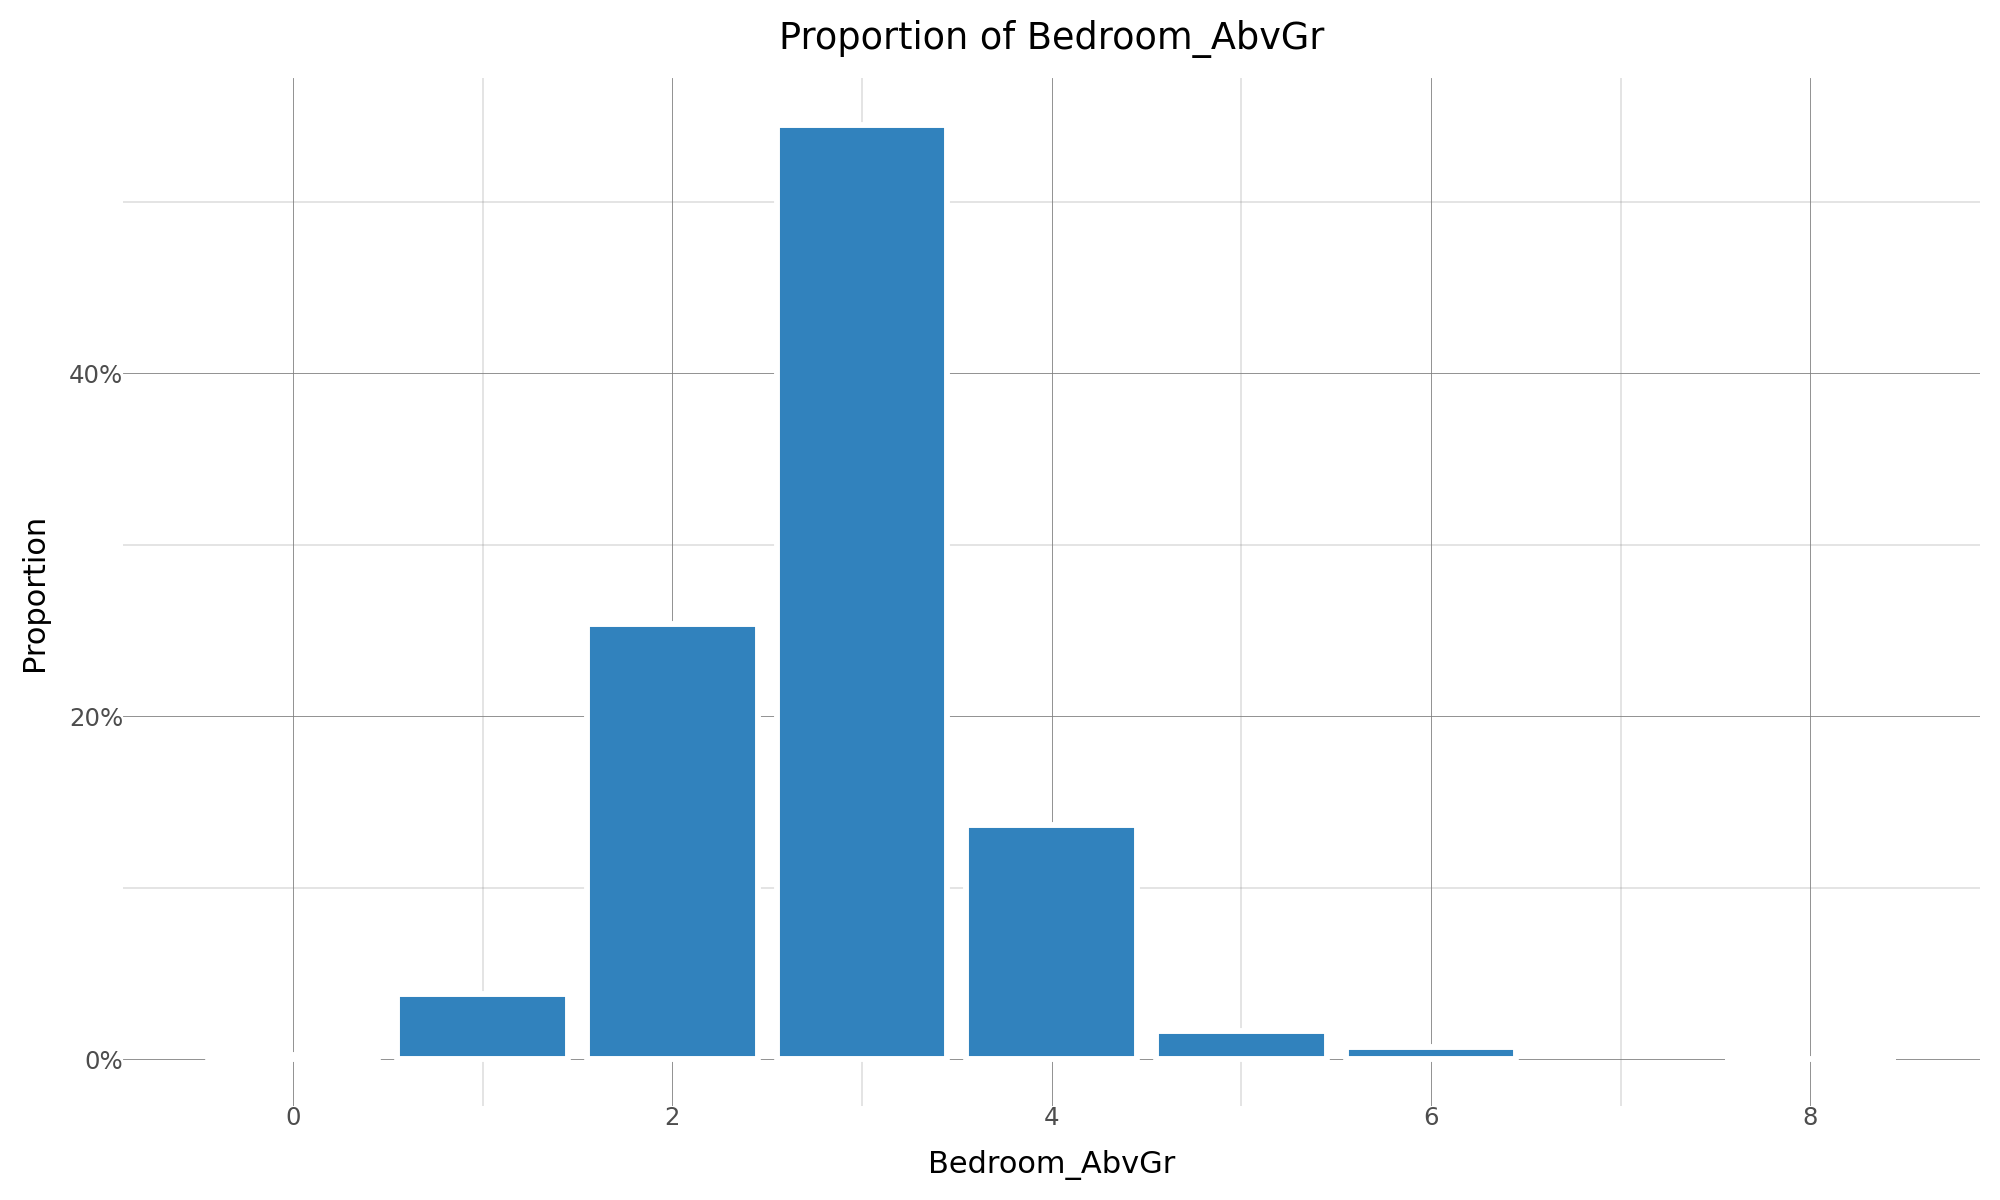

In [ ]:
p = (
    ggplot(prop_counts_df, aes(x='Bedroom_AbvGr', y='proportion'))
    + geom_col(fill='#3182bd', color='white', size=1.2)   
    + scale_y_continuous(labels=lambda l: [f"{v:.0f}%" for v in l])
    + labs(title='Proportion of Bedroom_AbvGr', x='Bedroom_AbvGr', y='Proportion')
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        panel_grid_major=element_line(color='gray', size=0.3),
        panel_grid_minor=element_line(color='gray', size=0.15)
    )
)
p



In [17]:
grouped = ames.groupby('Bedroom_AbvGr').size().reset_index(name='n')
grouped.head(5)

,Bedroom_AbvGr,n
0,0,8
1,1,112
2,2,743
3,3,1597
4,4,400


In [19]:

grouped['prop'] = (
    grouped['n'] / grouped['n'].sum() * 100
).round(2)

grouped.head(5)

,Bedroom_AbvGr,n,prop
0,0,8,0.27
1,1,112,3.82
2,2,743,25.36
3,3,1597,54.51
4,4,400,13.65


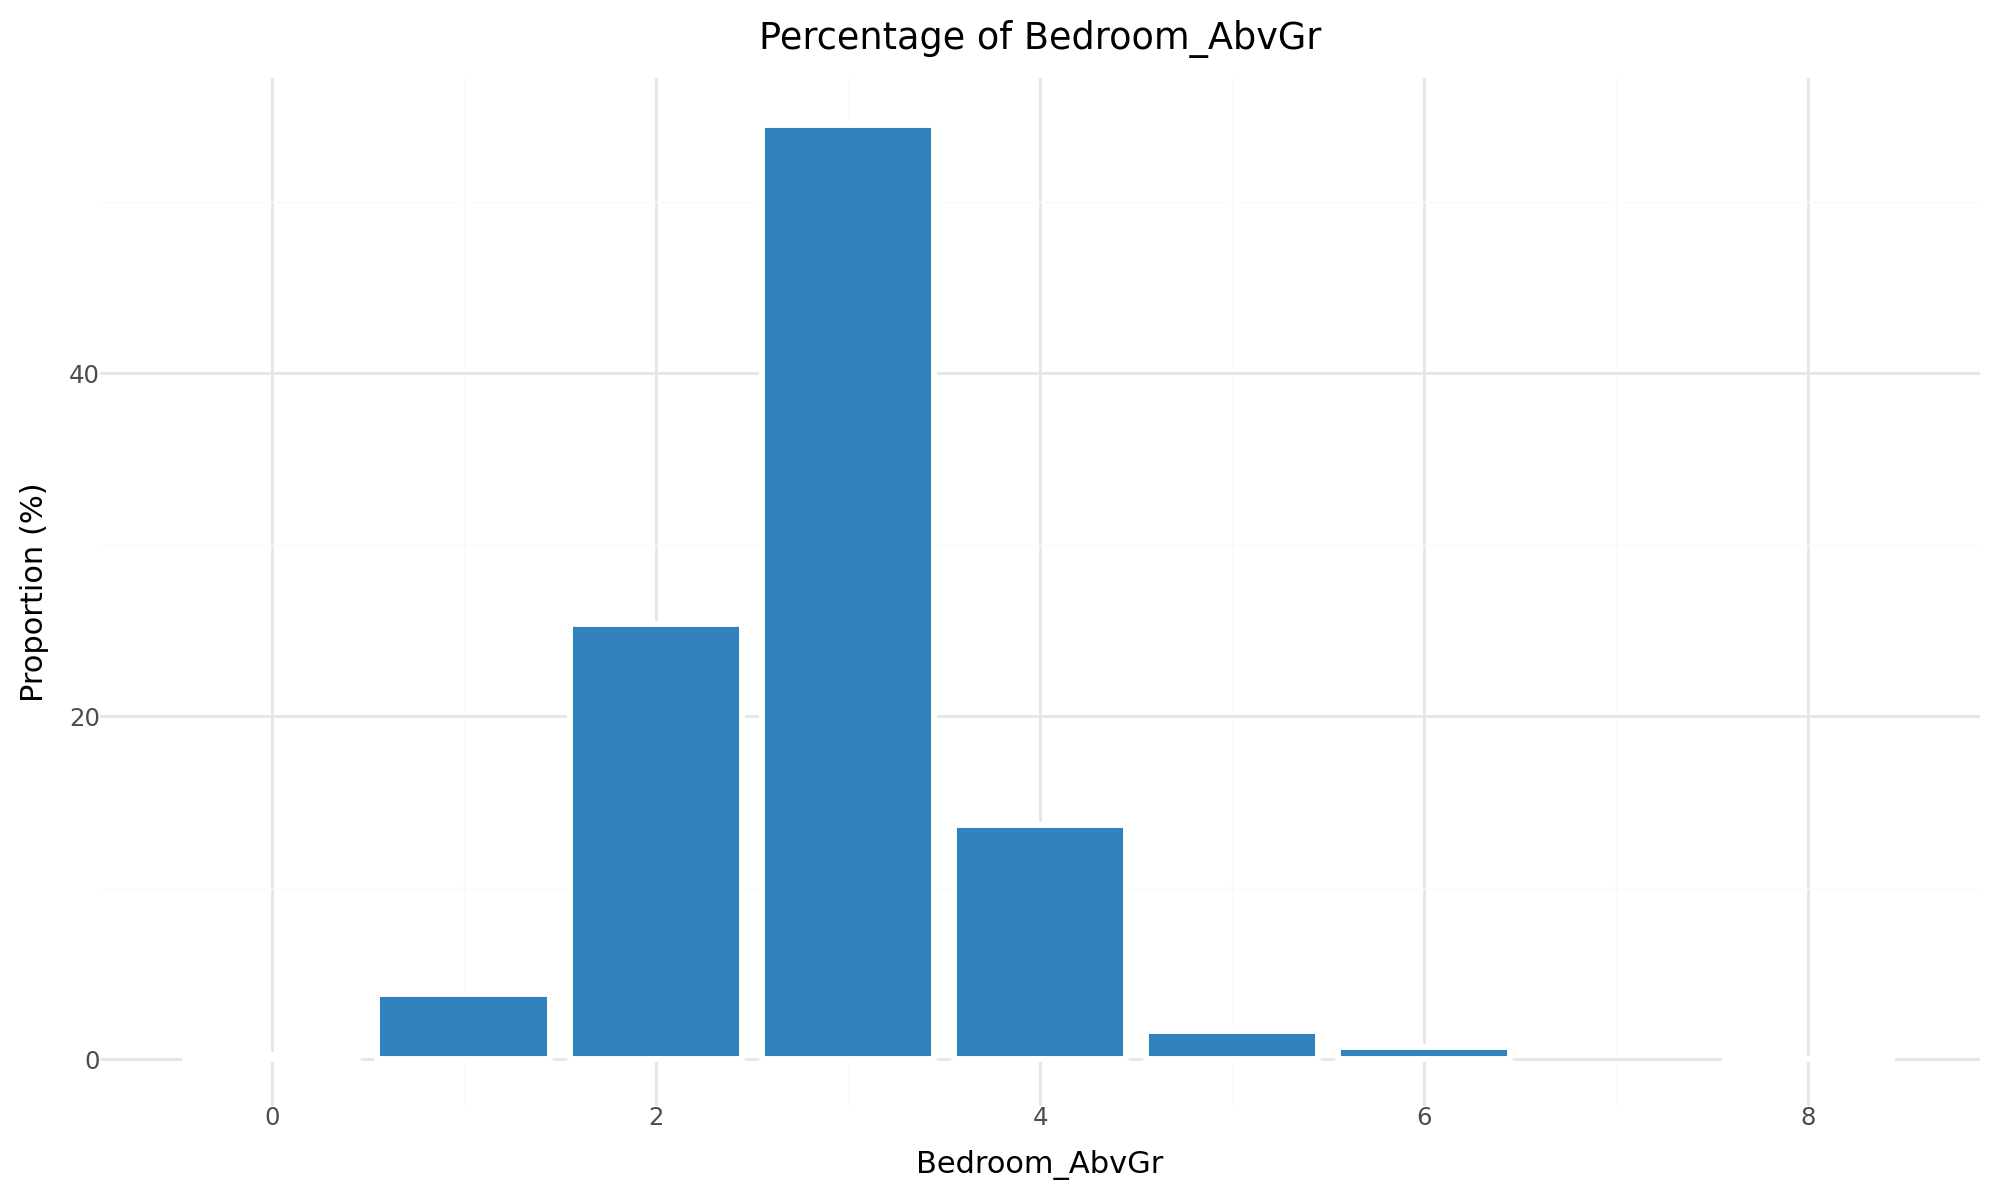

In [23]:
plt.style.use('default')
p = (
    ggplot(grouped, aes(x='Bedroom_AbvGr', y='prop'))
    + geom_col(fill="#3182bd", color="white", size=1.2)
    + labs(title="Percentage of Bedroom_AbvGr",
           x="Bedroom_AbvGr",
           y="Proportion (%)")
    + theme_minimal()
    + theme(figure_size=(10,6))
)

p

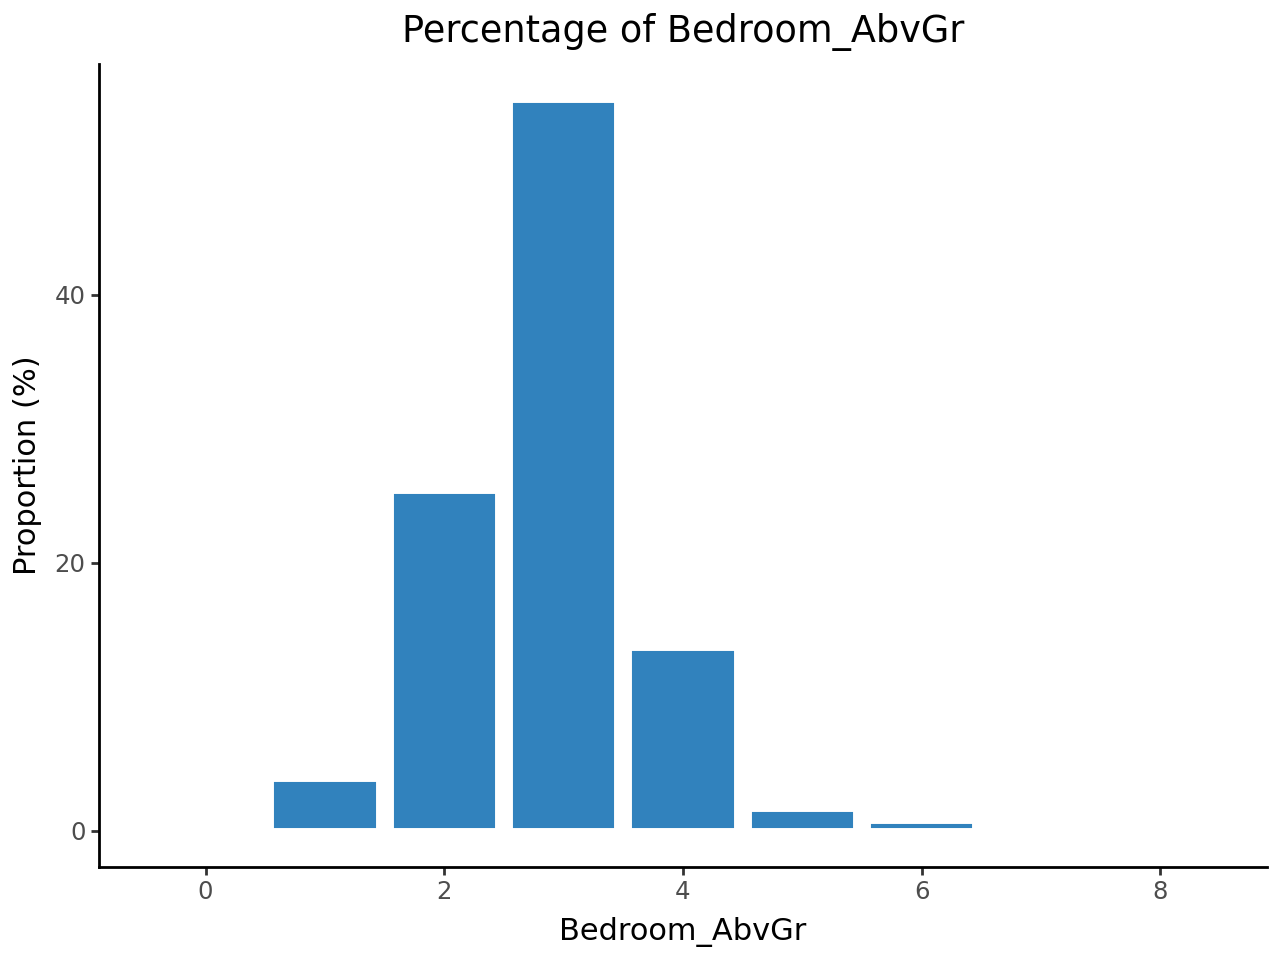

In [24]:
p = p + theme_classic()
p

In [25]:
grouped['Aux'] = 'casas'  

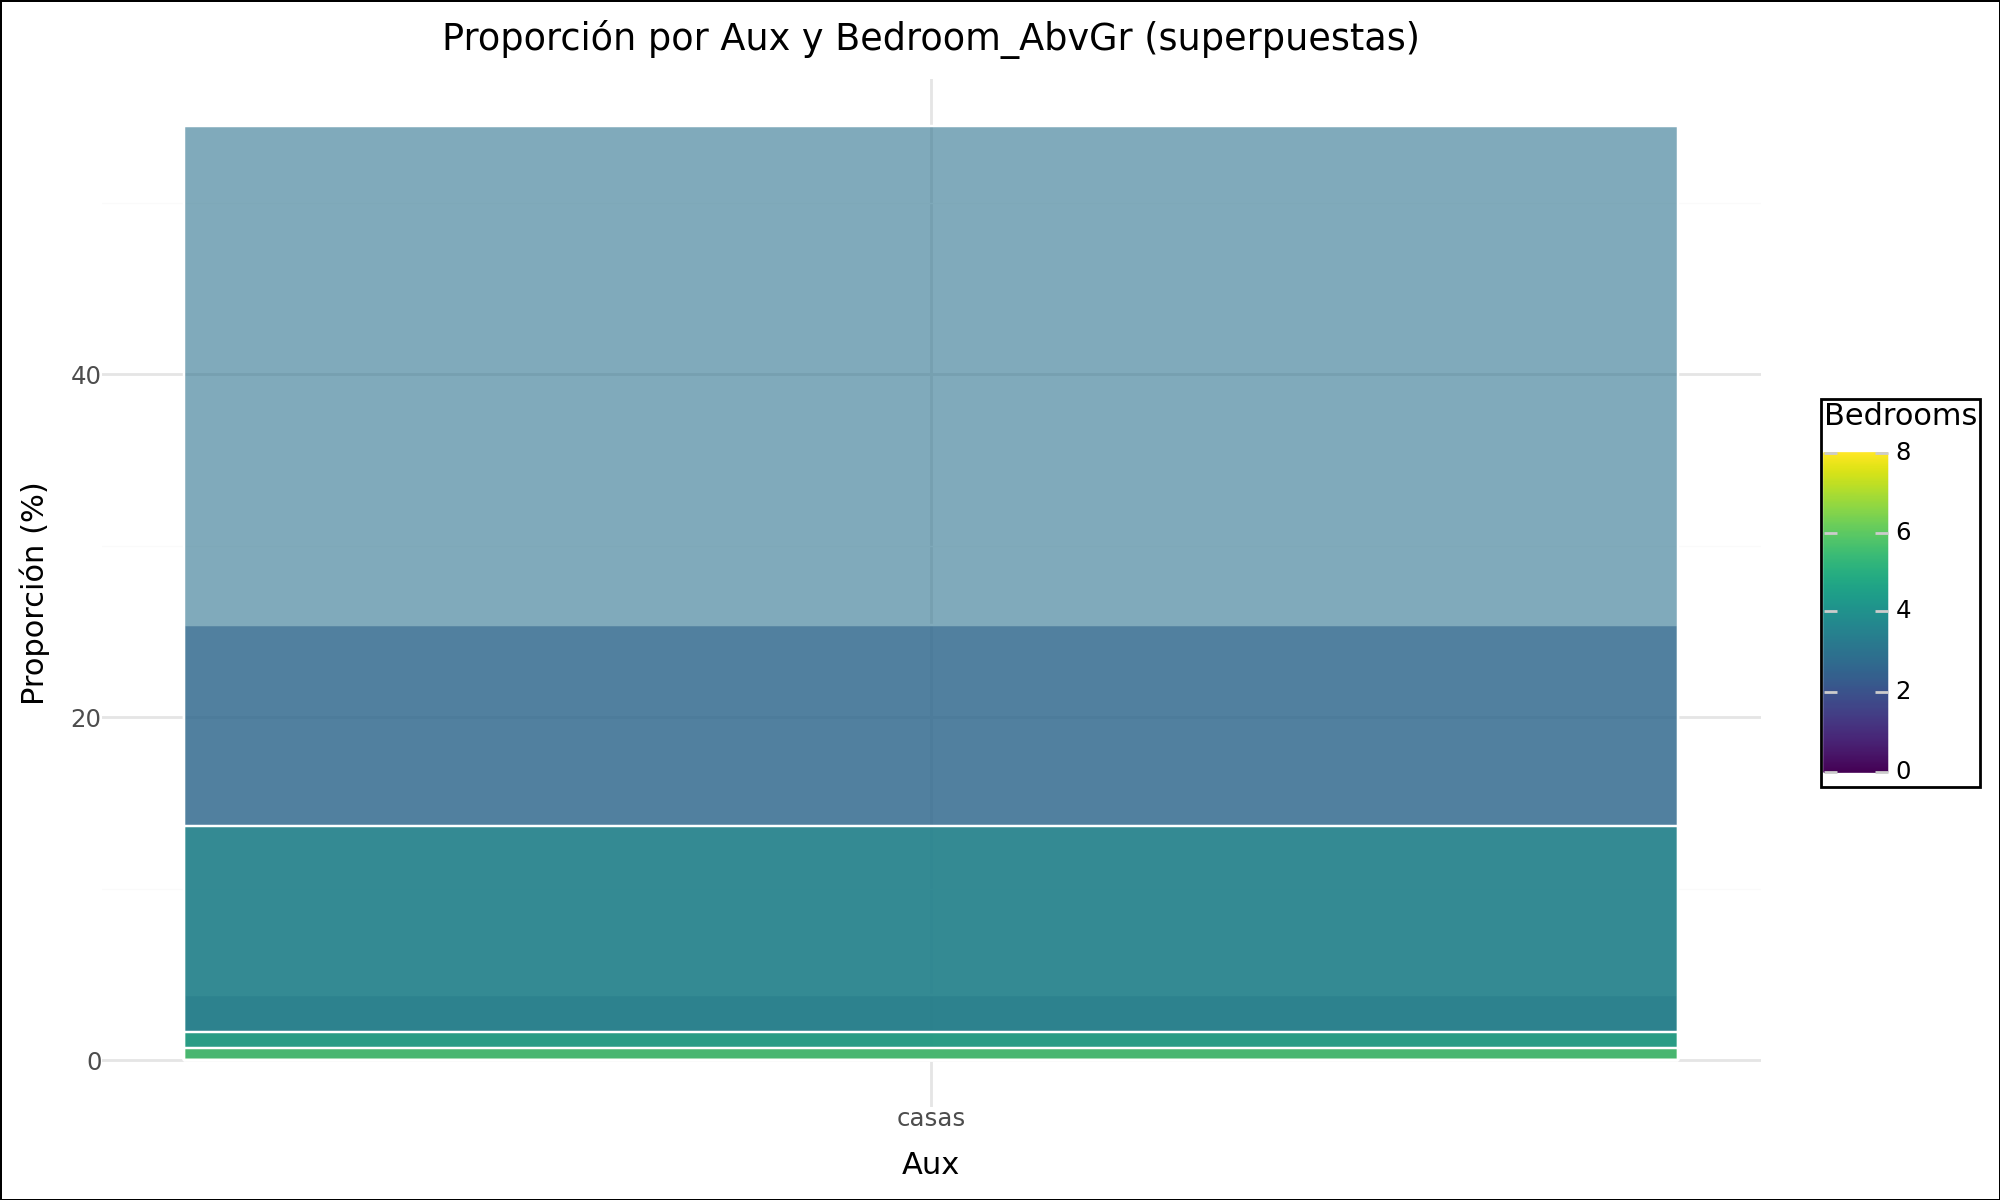

In [26]:
p = (
    ggplot(grouped, aes(x='Aux', y='prop', fill='Bedroom_AbvGr'))
    + geom_col(
        position='identity',   # superpone (no apila)
        color='white',
        alpha=0.6              # transparencia para ver solapamientos
    )
    + labs(
        title='Proporción por Aux y Bedroom_AbvGr (superpuestas)',
        x='Aux',
        y='Proporción (%)',
        fill='Bedrooms'
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        panel_background=element_rect(fill='white', color=None),
        plot_background=element_rect(fill='white', color=None),
        legend_background=element_rect(fill='white', color=None),
        legend_key=element_rect(fill='white', color=None)
    )
)
p

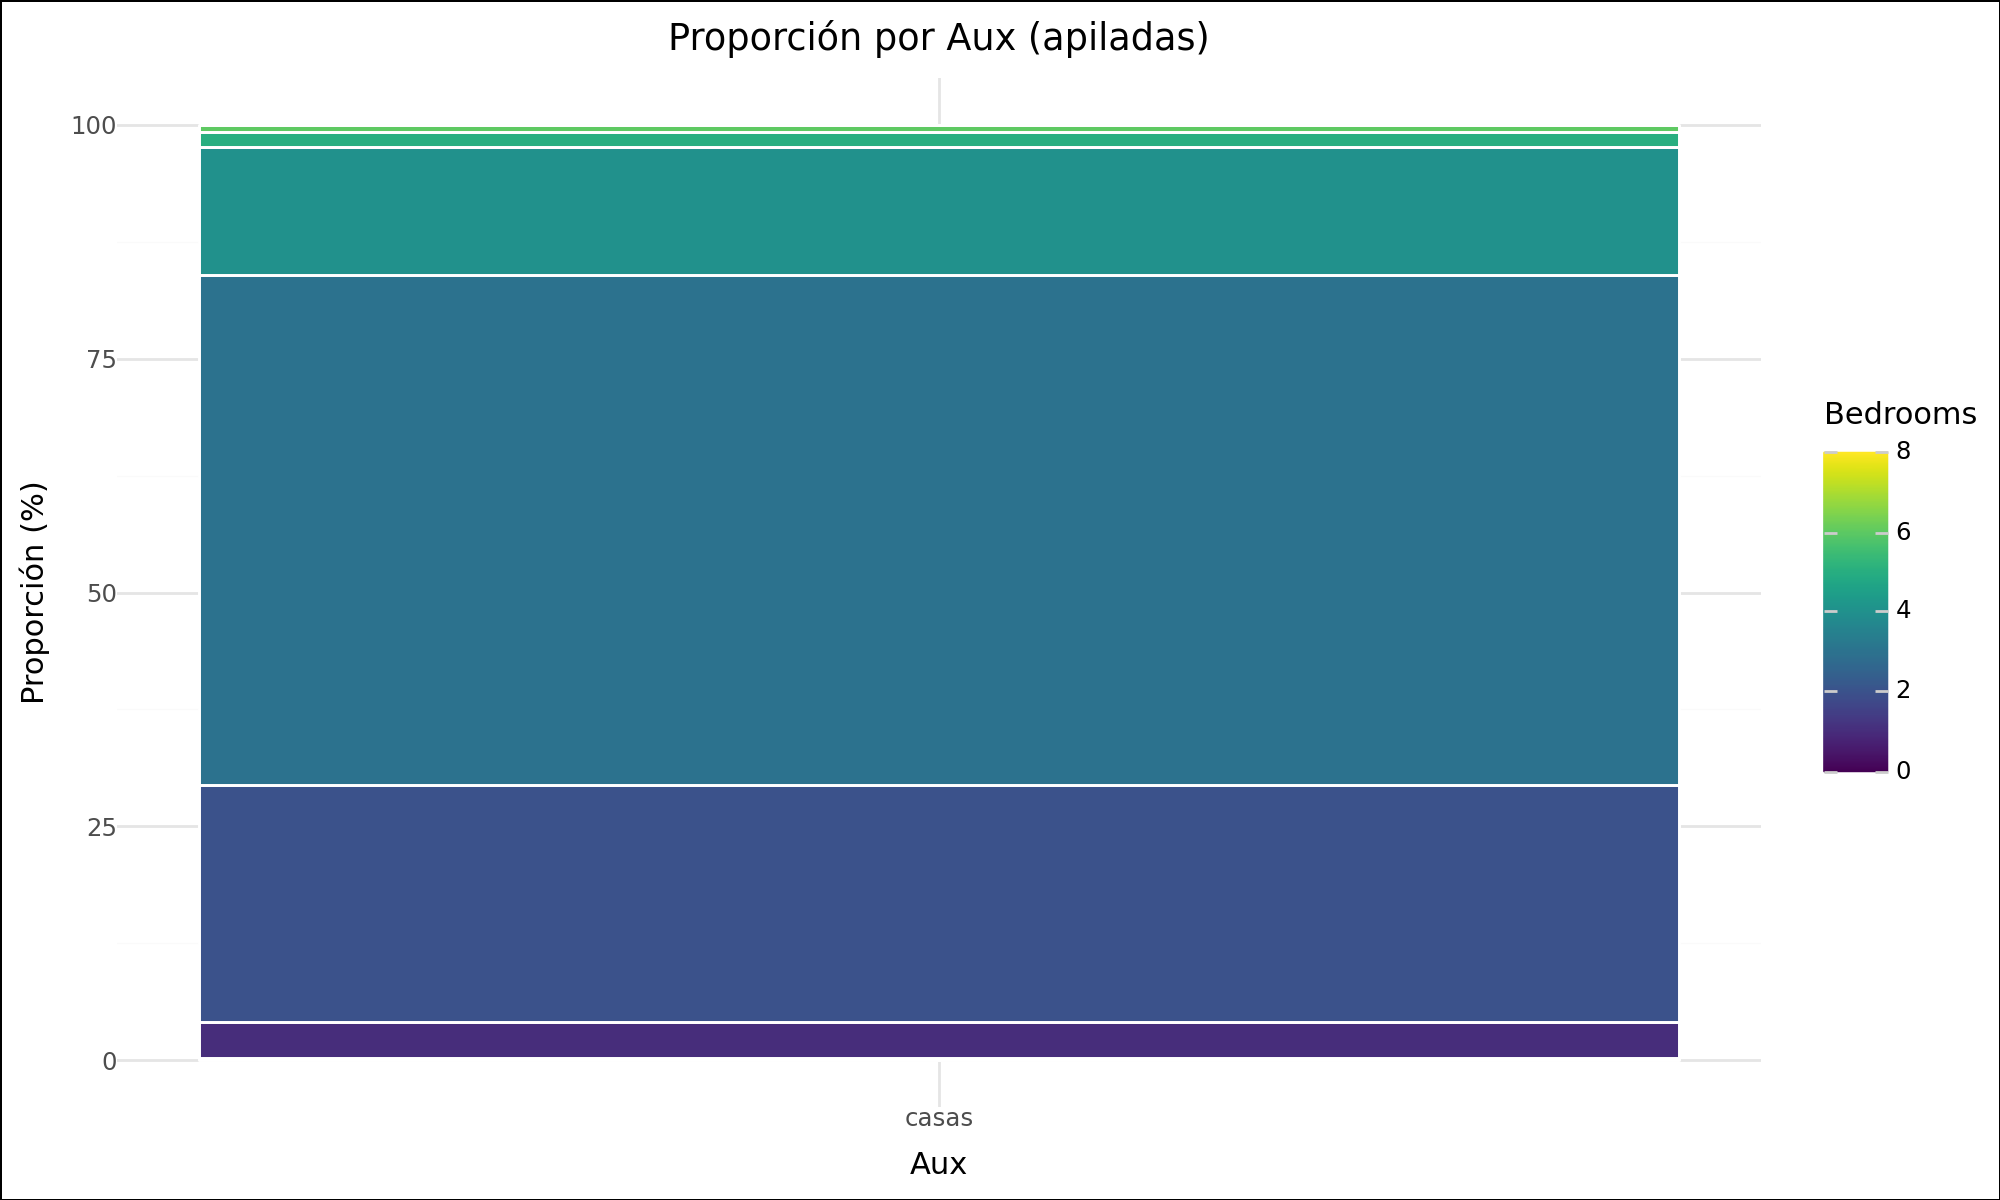

In [27]:
p = (
    ggplot(grouped, aes(x='Aux', y='prop', fill='Bedroom_AbvGr'))
    + geom_col(               # por defecto position='stack'
        color='white',
        size=0.6
    )
    + labs(
        title='Proporción por Aux (apiladas)',
        x='Aux',
        y='Proporción (%)',
        fill='Bedrooms'
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        panel_background=element_rect(fill='white', color=None),
        plot_background=element_rect(fill='white', color=None)
    )
)
p

### forma 2

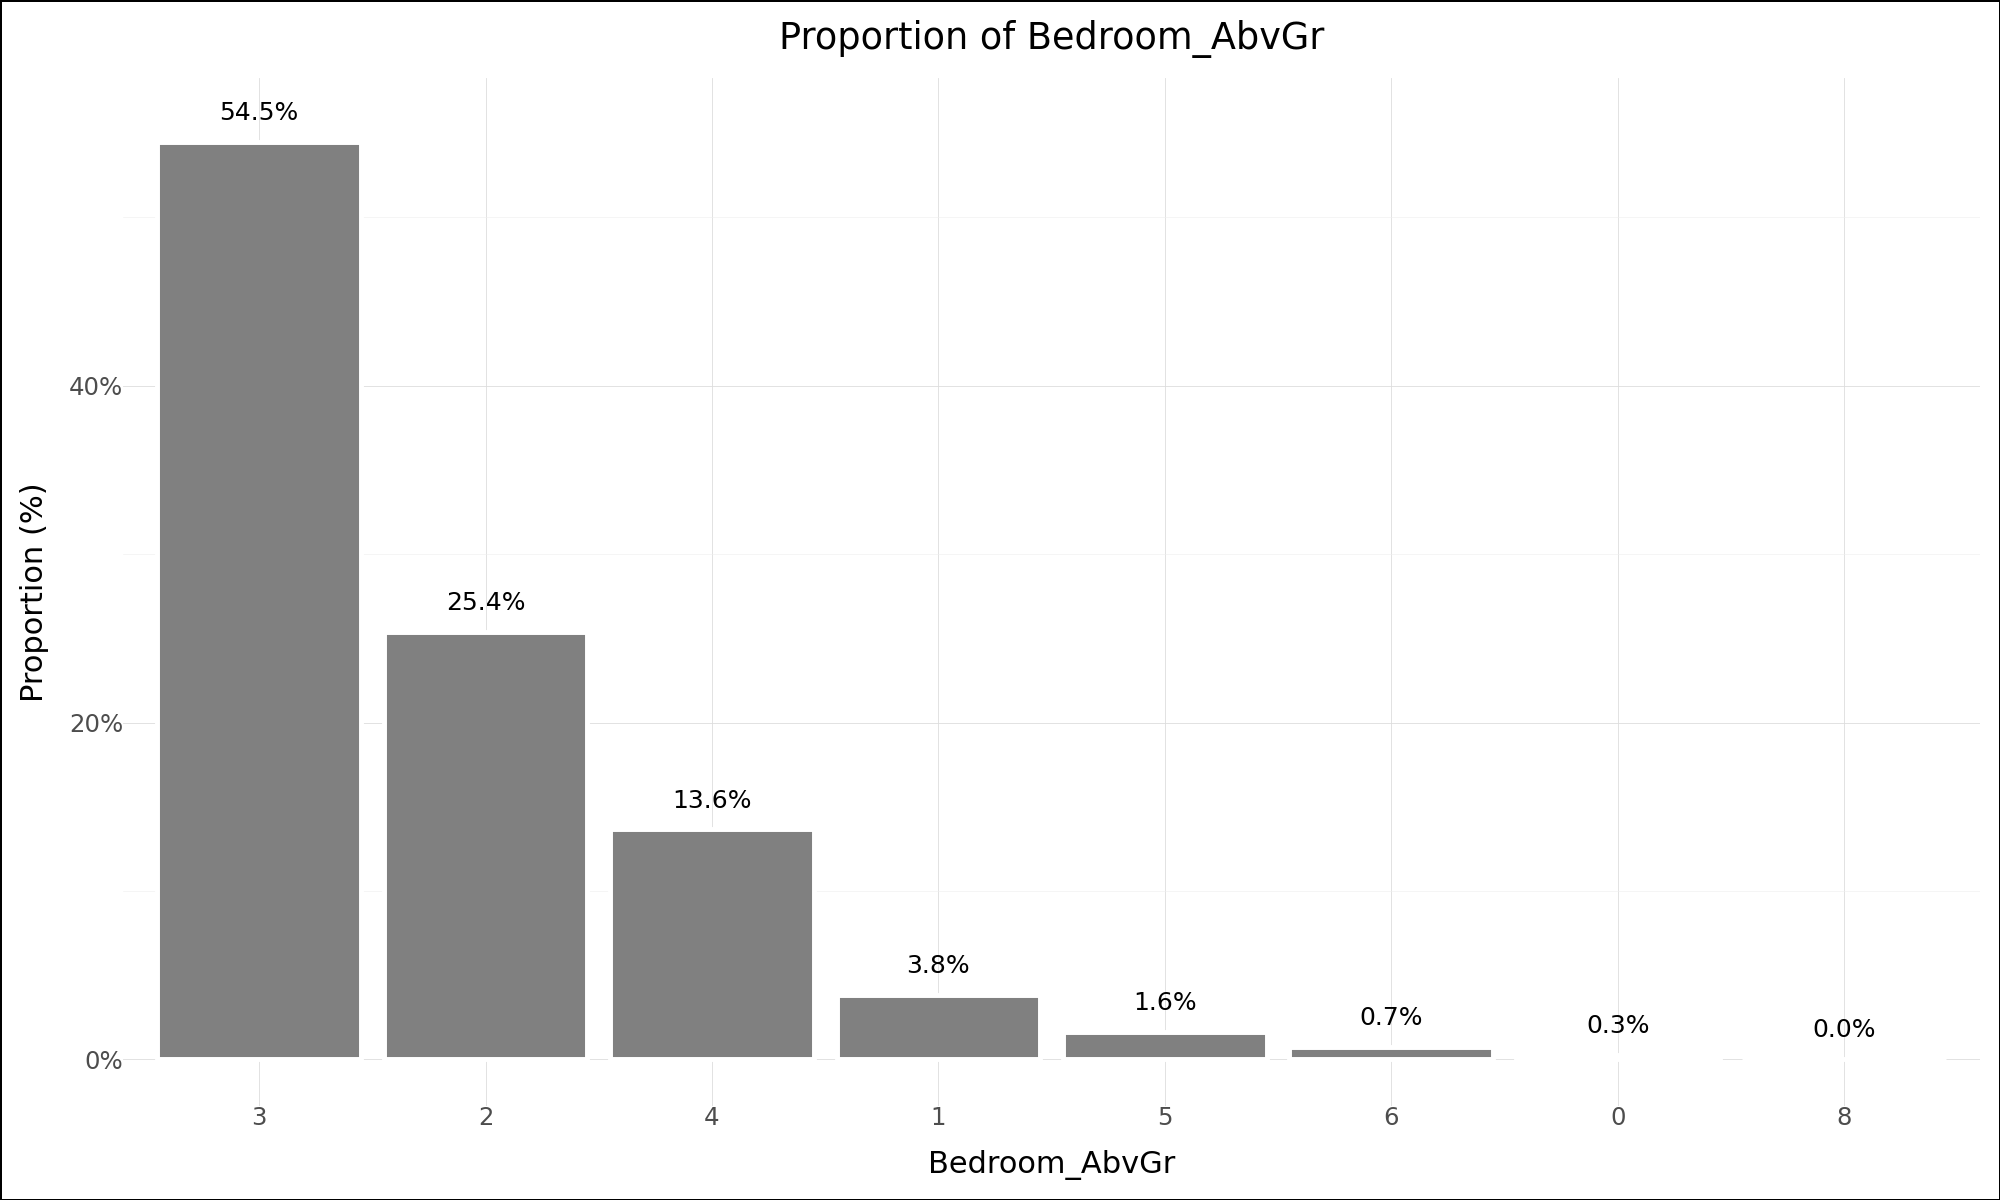

In [28]:
# Tabla de proporciones
Tabla = ames.groupby('Bedroom_AbvGr').size().to_frame('Total').reset_index()
Tabla['Prop'] = Tabla['Total'] / Tabla['Total'].sum()
Tabla['Prop100'] = (Tabla['Prop'] * 100).round(2)

# Orden por proporción descendente y respetar ese orden en el eje X
Tabla = Tabla.sort_values('Prop', ascending=False)
Tabla['Bedroom_AbvGr'] = pd.Categorical(Tabla['Bedroom_AbvGr'],
                                        categories=Tabla['Bedroom_AbvGr'],
                                        ordered=True)

# Gráfico
p = (
    ggplot(Tabla, aes(x='Bedroom_AbvGr', y='Prop'))
    + geom_col(fill='grey', color='white', size=1.0)
    + geom_text(
        aes(label=Tabla['Prop100'].round(1).astype(str) + '%'),
        va='bottom',
        size=9,
        nudge_y=0.01
    )
    + scale_y_continuous(labels=lambda l: [f"{v*100:.0f}%" for v in l])
    + labs(
        title='Proportion of Bedroom_AbvGr',
        x='Bedroom_AbvGr',
        y='Proportion (%)'
    )
    + theme_minimal()
    + theme(
        figure_size=(10, 6),
        panel_background=element_rect(fill='white', color=None),
        plot_background=element_rect(fill='white', color=None),
        legend_background=element_rect(fill='white', color=None),
        legend_key=element_rect(fill='white', color=None),
        panel_grid_major=element_line(color='#dddddd', size=0.3),
        panel_grid_minor=element_line(color='#eeeeee', size=0.2)
    )
)

p